# FINAL: additional plots

Supplementary figures (peak training-loss ratio, BTSP neuron % per layer, mean total score per layer (±1.96 SEM), period-metric correlations). Requires cached runs from `FINAL_code_only.ipynb` under `local/save/FINAL/`.

In [17]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt

def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from visualize_webapp.app import _opt_display, scan_results, _sort_optimizer_ids
from visualize_webapp.notebook.final.final_experiment_display import (
	ExperimentDisplayLabels,
	normalize_experiment_display_label,
	rename_experiments_for_labels,
	sort_experiment_display_names,
)
from visualize_webapp.notebook.final.final_additional_plots_helpers import (
	apply_presentation_defaults,
	aggregate_layer_metric_mean_sem,
	build_btsp_neuron_pct_rows,
	build_layer_mean_score_rows,
	build_layer_period_score_rows,
	print_mean_score_across_layers,
	build_btsp_neuron_pct_segment_rows,
	build_peak_ratio_df,
	build_period_metrics_df,
	cat2_shuffle_recover_reinforce_labels,
	facet_bar_by_experiment_cat12,
	facet_bar_by_experiment_row,
	facet_box_welch_cat12,
	load_all_results_from_cache,
	overlay_layer_group_mean_regression,
	overlay_layer_per_optimizer_regression,
	pool_btsp_mean_over_experiments,
	plot_btsp_neuron_pct_segment_trajectories,
	plot_btsp_pooled_optimizer_layer_bars,
	build_latex_table,
	plot_correlation_matrices_pooled_by_experiment,
	plot_correlation_matrix_global_pool,
	plot_correlations_per_experiment,
	plot_correlations_pooled_by_optimizer,
	plot_debug_training_loss_peaks,
	find_peaks_params_label,
	print_peak_ratio_pooled_summaries,
	_sort_layer_display_names,
	_fixed_ylim_for_metric,
)

SAVE_DIR = "local/save/FINAL/"
PLOT_DIR = "local/save/plots/FINAL/additional/"

SIG_BRACKET_STEP_FRAC = 0.086
SIG_BRACKET_YLIM_PAD_FRAC = 0.175
_CAT2_EARLY_ZOOM_N_TRIALS = 4
_CAT2_EARLY_ZOOM_MAX_ITER = 400

_EXPER_LABEL_SHUFFLE_ALL = r"$\text{Shuffle}_{all}$"
_EXPER_LABEL_SHUFFLE_NOPRE = "Control global (✗PT)"
_EXPER_LABEL_SEQ_NOPRE = "Control sequential (✗PT)"
_EXPER_LABEL_SEQ_PRE = "Control sequential (✔PT)"
_EXPER_LABEL_SHUFFLE_SEQ = r"$\text{Shuffle}_{seq}$"
_EXPER_LABEL_NO_PRETRAIN = " Control (no pretrain)"

LABELS = ExperimentDisplayLabels(
	shuffle_all=_EXPER_LABEL_SHUFFLE_ALL,
	shuffle_nopre=_EXPER_LABEL_SHUFFLE_NOPRE,
	seq_nopre=_EXPER_LABEL_SEQ_NOPRE,
	seq_pre=_EXPER_LABEL_SEQ_PRE,
	shuffle_seq=_EXPER_LABEL_SHUFFLE_SEQ,
	no_pretrain=_EXPER_LABEL_NO_PRETRAIN,
)


def rename_experiments(eid: str) -> str:
	return normalize_experiment_display_label(
		rename_experiments_for_labels(eid, LABELS), LABELS
	)


def _sort_experiment_display_names(labels: Iterable[str]) -> list[str]:
	return sort_experiment_display_names(labels, LABELS)

USE_T_START_INV = False
_CORR_MAT_COLS = ["activation_angle", "total_length_iter", "robustness_score", "t_start"+("_inv" if USE_T_START_INV else "")]
_CORR_MAT_LABELS = ["ang", "len", "rob", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"]
_CORR_PAIRS = [
	("activation_angle", "total_length_iter", "angle", "length"),
	("activation_angle", "robustness_score", "angle", "robustness"),
	("total_length_iter", "robustness_score", "length", "robustness"),
	("activation_angle", "t_start"+("_inv" if USE_T_START_INV else ""), "angle", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
	("total_length_iter", "t_start"+("_inv" if USE_T_START_INV else ""), "length", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
	("robustness_score", "t_start"+("_inv" if USE_T_START_INV else ""), "robustness", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
]

_PLOT_KW = dict(
	plot_dir=PLOT_DIR,
	sig_bracket_step_frac=SIG_BRACKET_STEP_FRAC,
	sig_bracket_ylim_pad_frac=SIG_BRACKET_YLIM_PAD_FRAC,
	sort_experiment_names=_sort_experiment_display_names,
	labels=LABELS,
)

apply_presentation_defaults(PLOT_DIR)
tree = scan_results()
all_results = load_all_results_from_cache(tree, SAVE_DIR)

if not all_results:
	raise RuntimeError(
		f"No cached runs in {SAVE_DIR}. Run the load cell in FINAL_code_only.ipynb first."
	)
print(f"Loaded {len(all_results)} runs from cache; plots -> {PLOT_DIR}")

# --- find_peaks tuning (debug curves + peak-ratio boxplot) ---
FIND_PEAKS_KWARGS = {
	"prominence": 0.5,
	"distance": 12,
	"height": 1.5,
}
FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL = {
	"prominence": 3.0,
	"distance": 10,
	"height": 1.5,
}
TRAIN_LOSS_LINE_ALPHA = 0.2
PEAK_MARKER_SIZE = 22.0
PEAK_MARKER_LINEWIDTH = 0.4


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 40 runs from cache; plots -> local/save/plots/FINAL/additional/


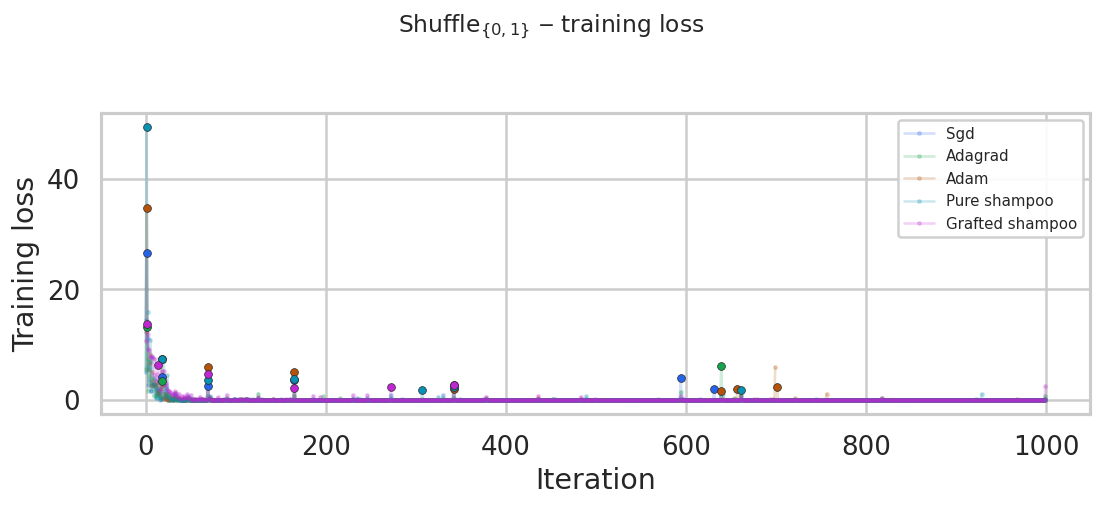

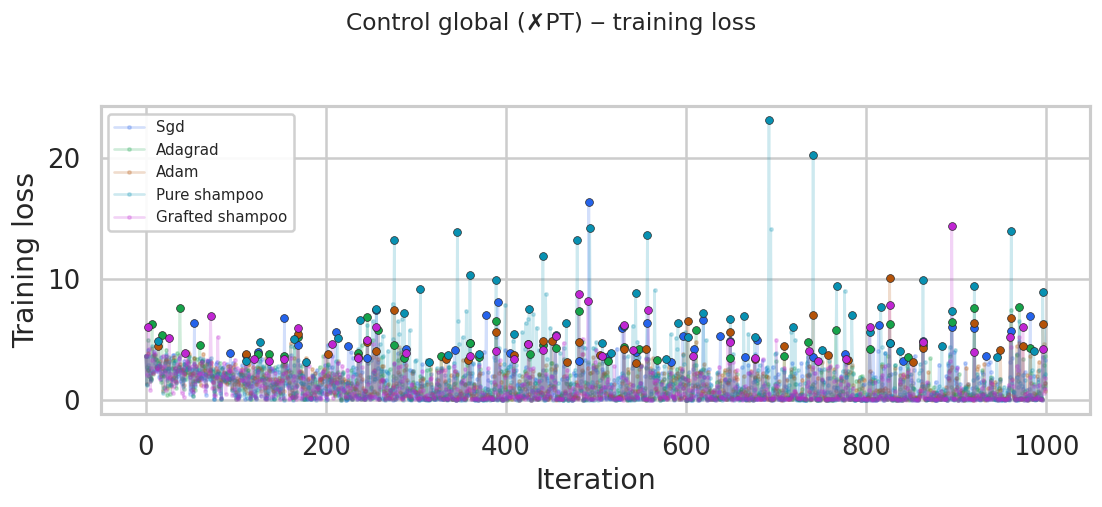

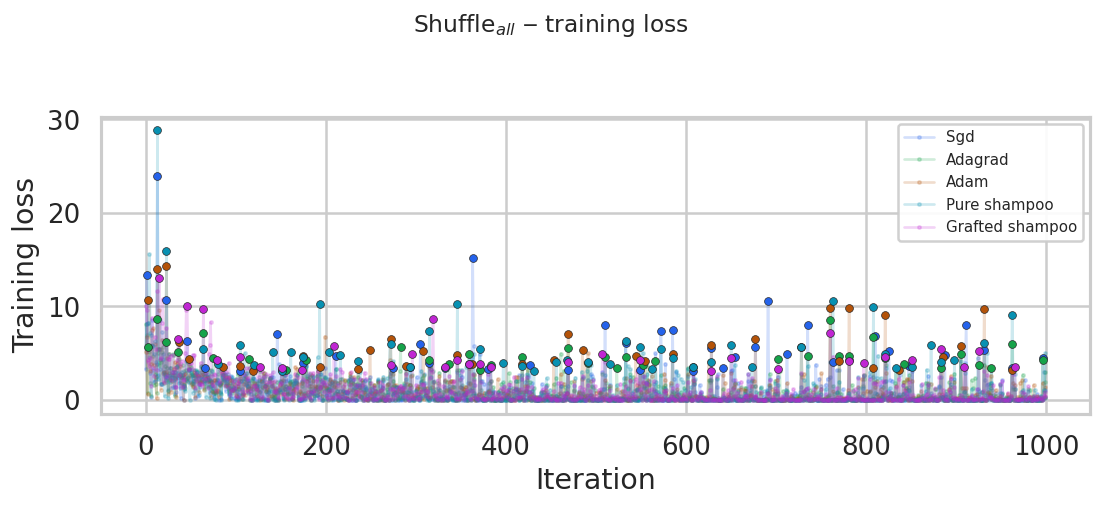

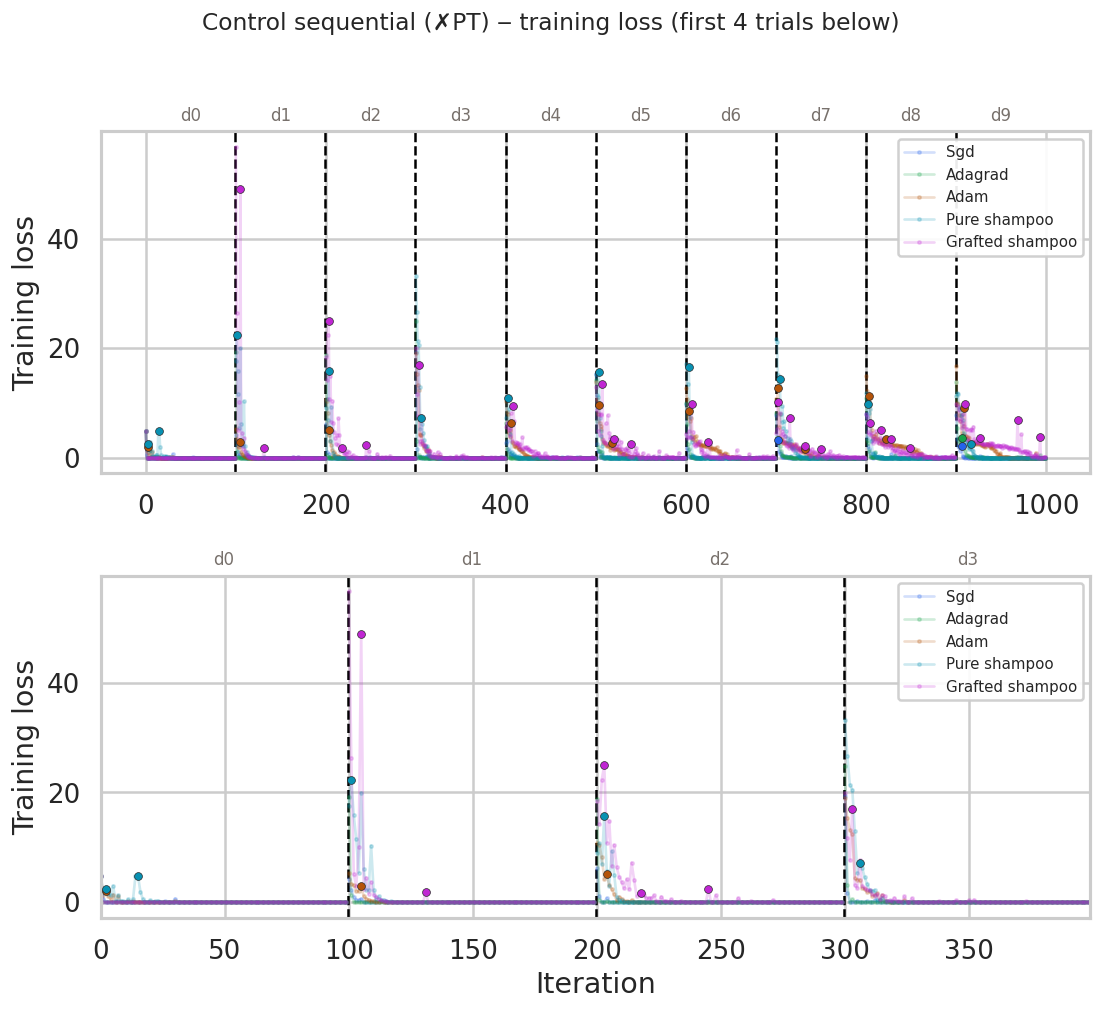

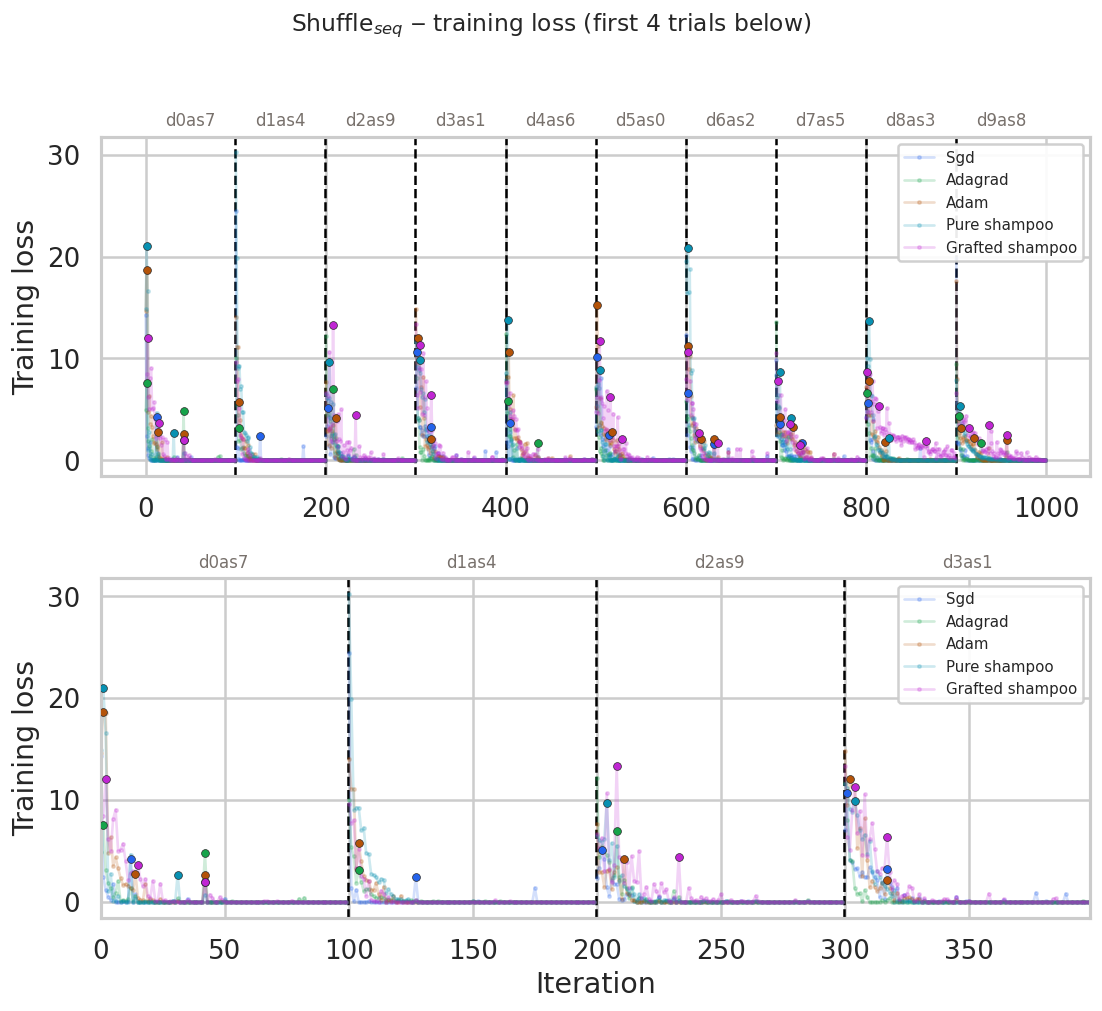

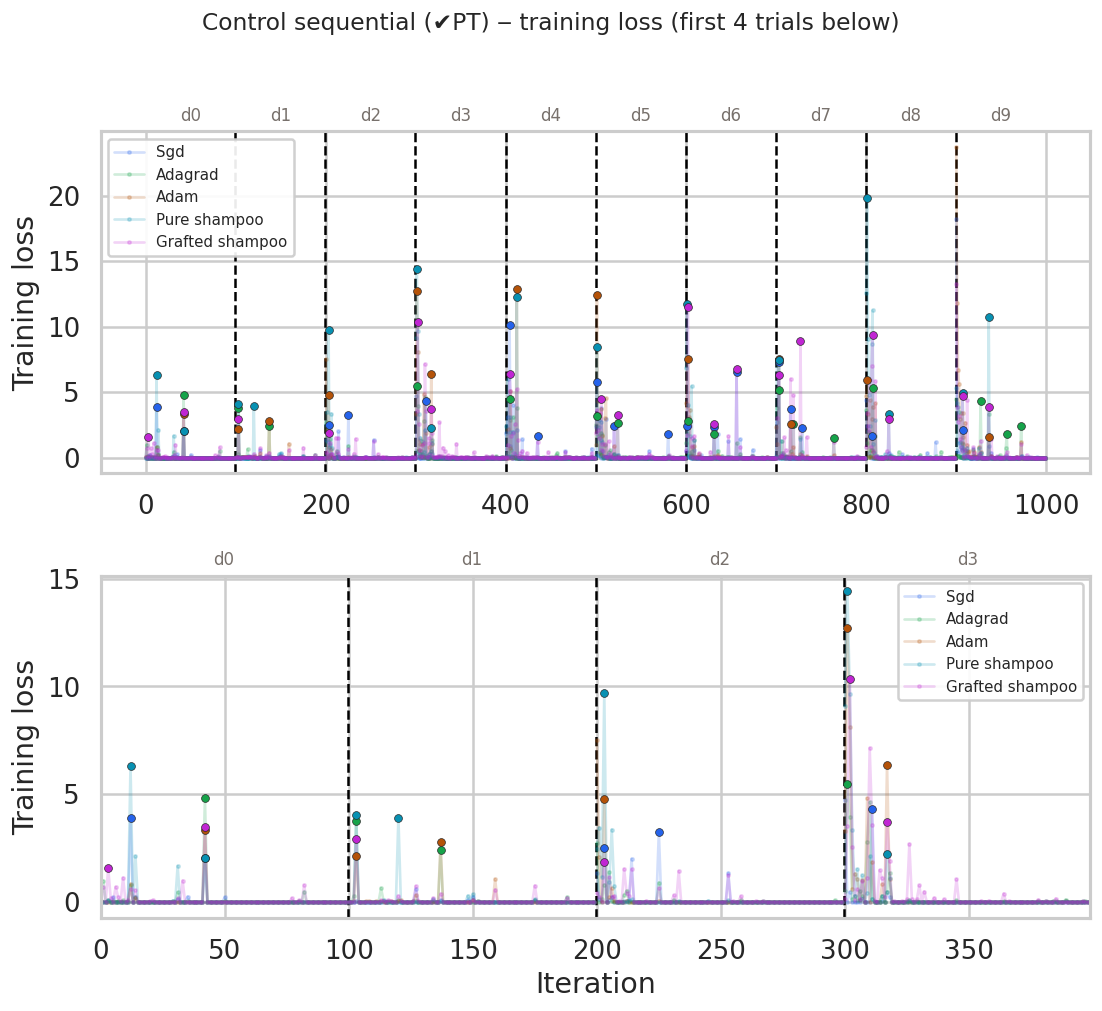

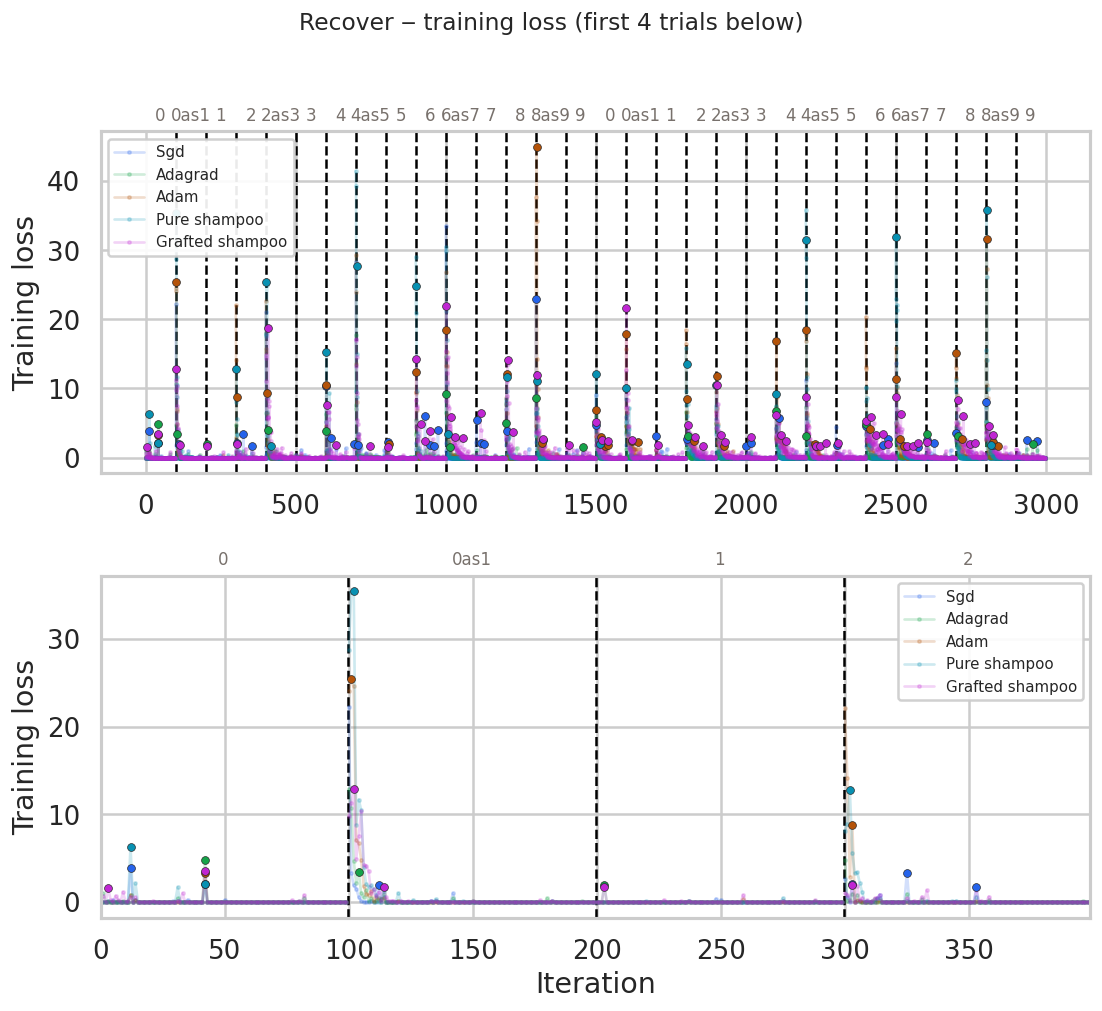

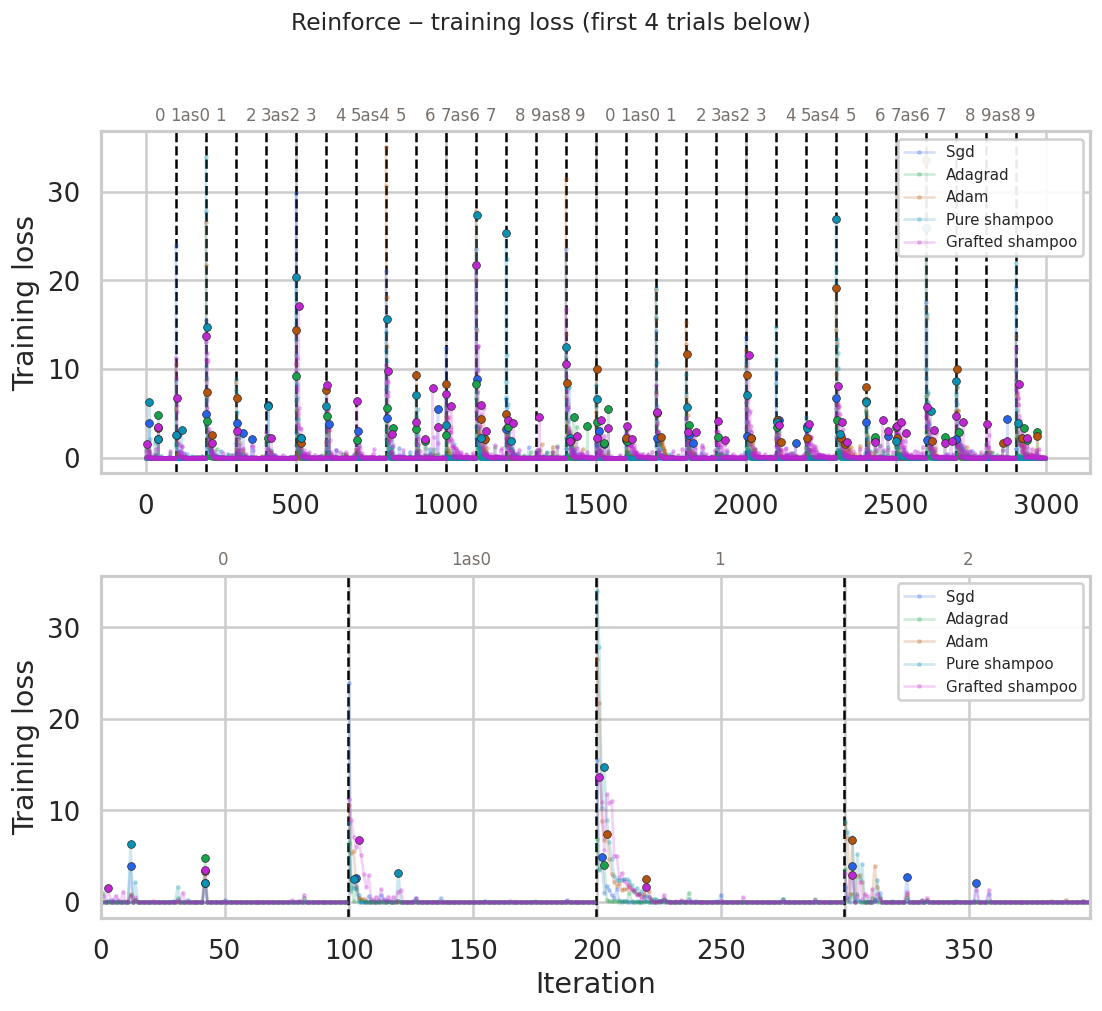

Saved additional_debug_training_loss_peaks_*.pdf


In [2]:
# Debug: training loss curves + find_peaks markers (tune FIND_PEAKS_KWARGS in setup cell)
plot_debug_training_loss_peaks(
	tree,
	all_results,
	rename_fn=rename_experiments,
	plot_dir=PLOT_DIR,
	cat2_early_zoom_n_trials=_CAT2_EARLY_ZOOM_N_TRIALS,
	cat2_early_zoom_max_iter=_CAT2_EARLY_ZOOM_MAX_ITER,
	category_only=True,
	show=True,
	find_peaks_kwargs=FIND_PEAKS_KWARGS,
	find_peaks_kwargs_control_global_shuffle_all=FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL,
	line_alpha=TRAIN_LOSS_LINE_ALPHA,
	peak_marker_size=PEAK_MARKER_SIZE,
	peak_marker_linewidth=PEAK_MARKER_LINEWIDTH,
)
print("Saved additional_debug_training_loss_peaks_*.pdf")


peak_ratio rows (one per peak): 1113
experiment                  optimizer_id          
$\text{Shuffle}_{\{0,1\}}$  adagrad_lr0.01             3
                            adam_lr0.0005              8
                            grafted_shampoo_lr0.01     6
                            pure_shampoo_lr0.01        7
                            sgd_lr0.01                 7
$\text{Shuffle}_{all}$      adagrad_lr0.01            39
                            adam_lr0.0005             38
                            grafted_shampoo_lr0.01    33
                            pure_shampoo_lr0.01       48
                            sgd_lr0.01                41
$\text{Shuffle}_{seq}$      adagrad_lr0.01            14
                            adam_lr0.0005             21
                            grafted_shampoo_lr0.01    25
                            pure_shampoo_lr0.01       14
                            sgd_lr0.01                16
Control global (✗PT)        adagrad_lr0.01            40


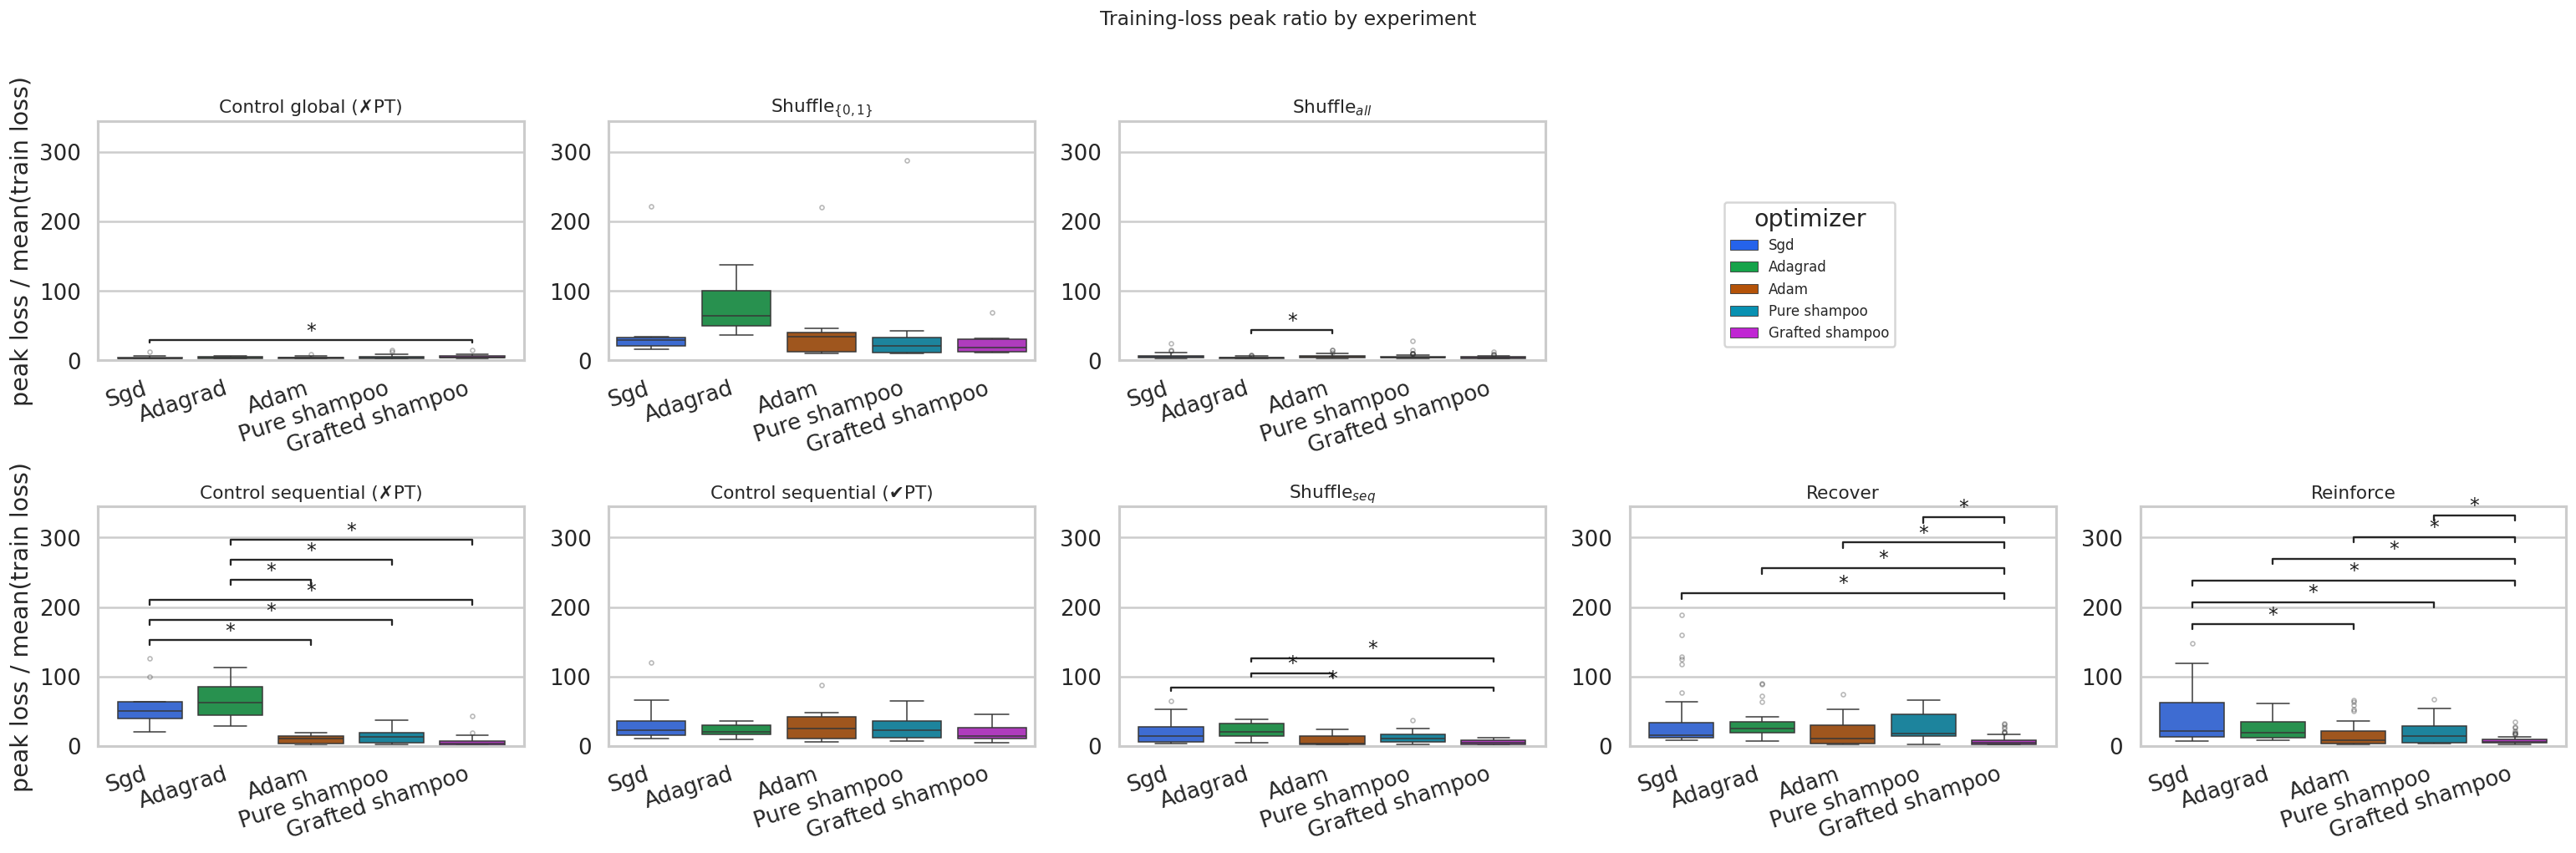

Saved additional_peak_ratio_by_experiment.pdf


In [3]:
# Peak ratio: one boxplot point per detected peak — (peak loss / mean train loss)
_fp_label = (
	f"default: {find_peaks_params_label(FIND_PEAKS_KWARGS)}; "
	f"control global / shuffle all: {find_peaks_params_label(FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL)}"
)
df_peak = build_peak_ratio_df(
	tree,
	rename_fn=rename_experiments,
	category_only=True,
	find_peaks_kwargs=FIND_PEAKS_KWARGS,
	find_peaks_kwargs_control_global_shuffle_all=FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL,
)
print(f"peak_ratio rows (one per peak): {len(df_peak)}")
if not df_peak.empty:
	print(df_peak.groupby(["experiment", "optimizer_id"]).size().to_string())
	print_peak_ratio_pooled_summaries(
		df_peak,
		labels=LABELS,
		sort_experiment_names=_sort_experiment_display_names,
	)

if not df_peak.empty:
	ylim = _fixed_ylim_for_metric(
		df_peak,
		"peak_ratio",
		"experiment",
		sort_experiment_names=_sort_experiment_display_names,
		sig_bracket_ylim_pad_frac=SIG_BRACKET_YLIM_PAD_FRAC,
	)
	facet_box_welch_cat12(
		df_peak,
		"peak_ratio",
		"experiment",
		f"Training-loss peak ratio by experiment",# (find_peaks: {_fp_label})",
		r"peak loss / mean(train loss)",
		"additional_peak_ratio_by_experiment.pdf",
		fixed_ylim=ylim,
		show=True,
		**_PLOT_KW,
	)
	print("Saved additional_peak_ratio_by_experiment.pdf")
else:
	print("df_peak empty — skip peak-ratio plot")


btsp neuron-% rows (per run/layer): 200

Control global (✗PT) — per-optimizer slopes (/layer):
  Sgd: +7.8125  (R²=0.701)
  Adagrad: +7.8125  (R²=0.575)
  Adam: +2.3438  (R²=0.771)
  Pure shampoo: +6.2500  (R²=0.937)
  Grafted shampoo: +4.8438  (R²=0.950)

$\text{Shuffle}_{\{0,1\}}$ — per-optimizer slopes (/layer):
  Sgd: +0.4688  (R²=0.750)
  Adagrad: +0.3125  (R²=0.125)
  Adam: +0.6250  (R²=0.400)
  Pure shampoo: +2.0312  (R²=0.671)
  Grafted shampoo: +0.3125  (R²=0.500)

$\text{Shuffle}_{all}$ — per-optimizer slopes (/layer):
  Sgd: +3.9062  (R²=0.755)
  Adagrad: +1.4062  (R²=0.506)
  Adam: +2.8125  (R²=0.664)
  Pure shampoo: +4.8438  (R²=0.809)
  Grafted shampoo: +0.6250  (R²=0.500)

Control sequential (✗PT) — per-optimizer slopes (/layer):
  Sgd: +6.5625  (R²=0.878)
  Adagrad: +9.6875  (R²=0.867)
  Adam: +11.8750  (R²=0.618)
  Pure shampoo: +9.2188  (R²=0.923)
  Grafted shampoo: +14.3750  (R²=0.971)

Control sequential (✔PT) — per-optimizer slopes (/layer):
  Sgd: +0.7812  (R²=0.3

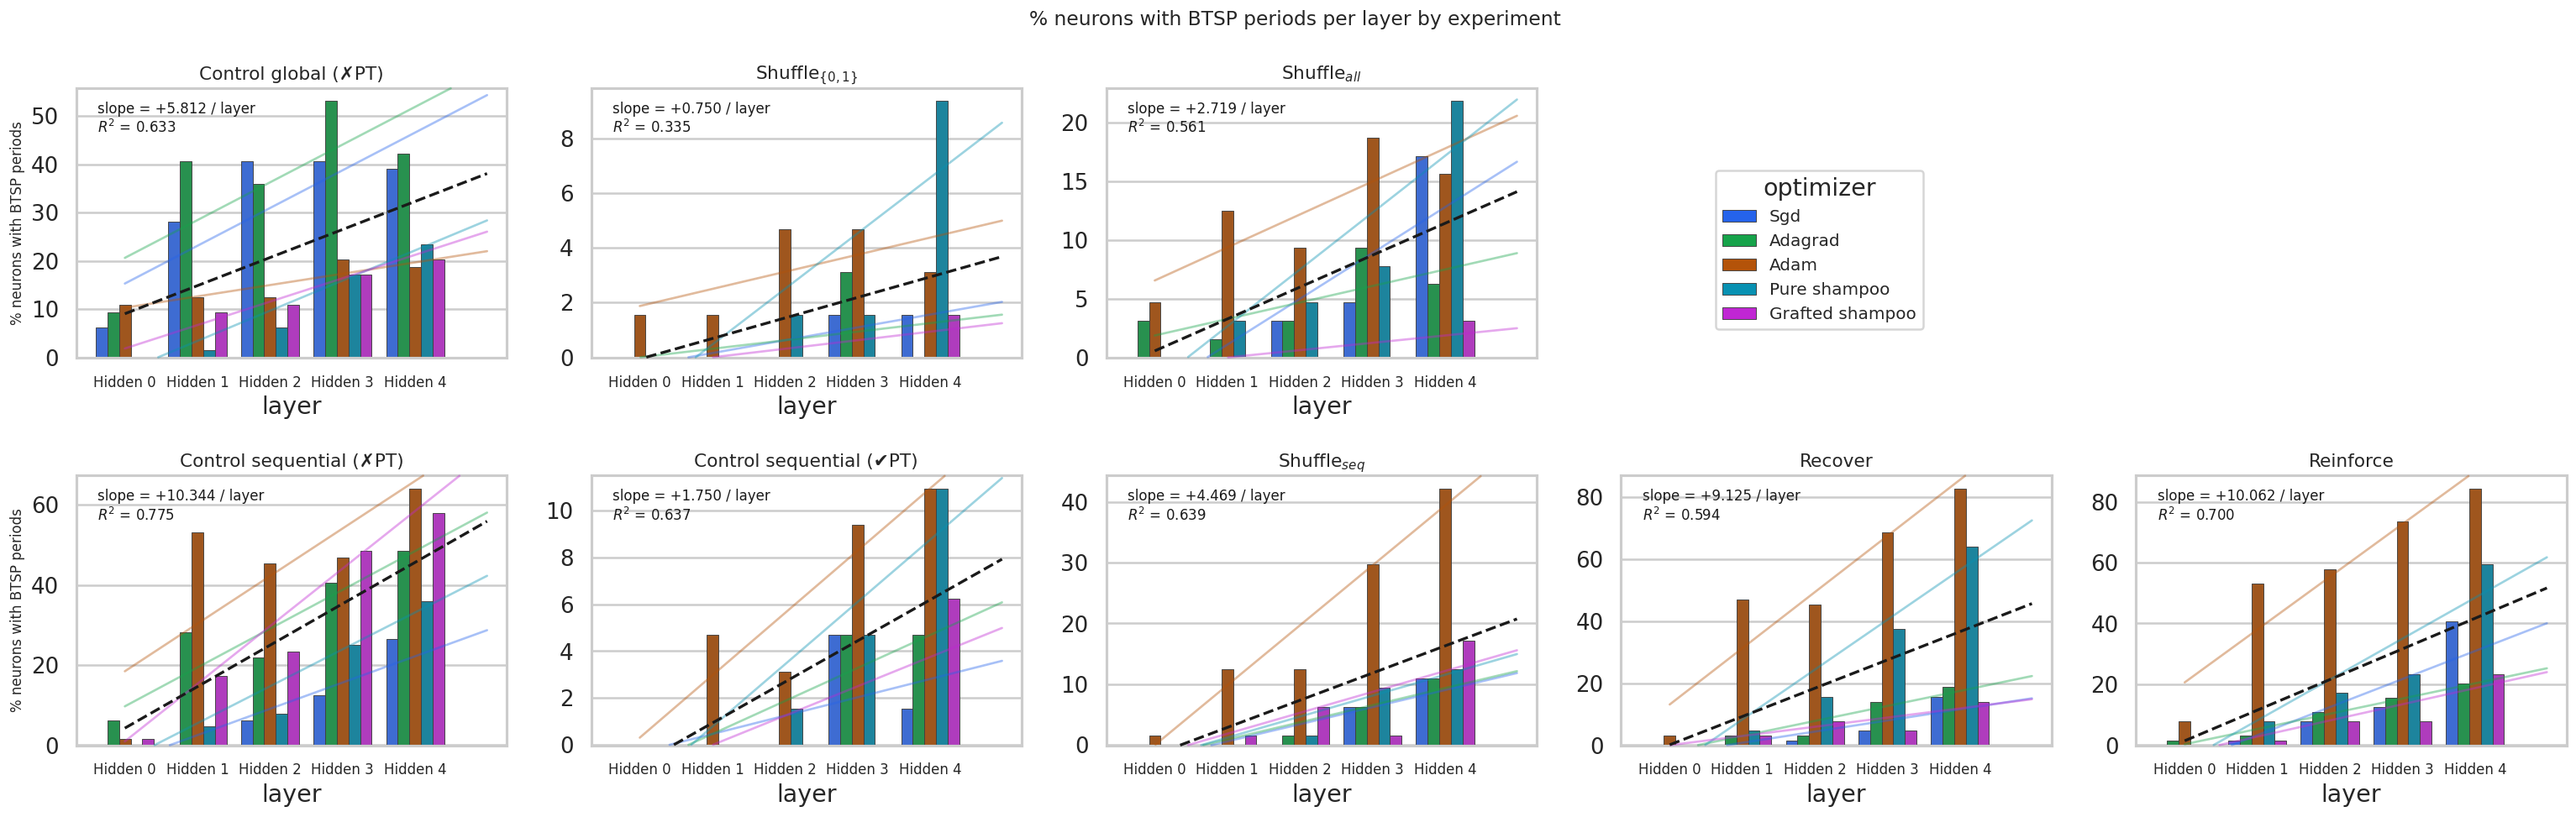

Saved additional_btsp_neuron_pct_per_layer_by_experiment.pdf


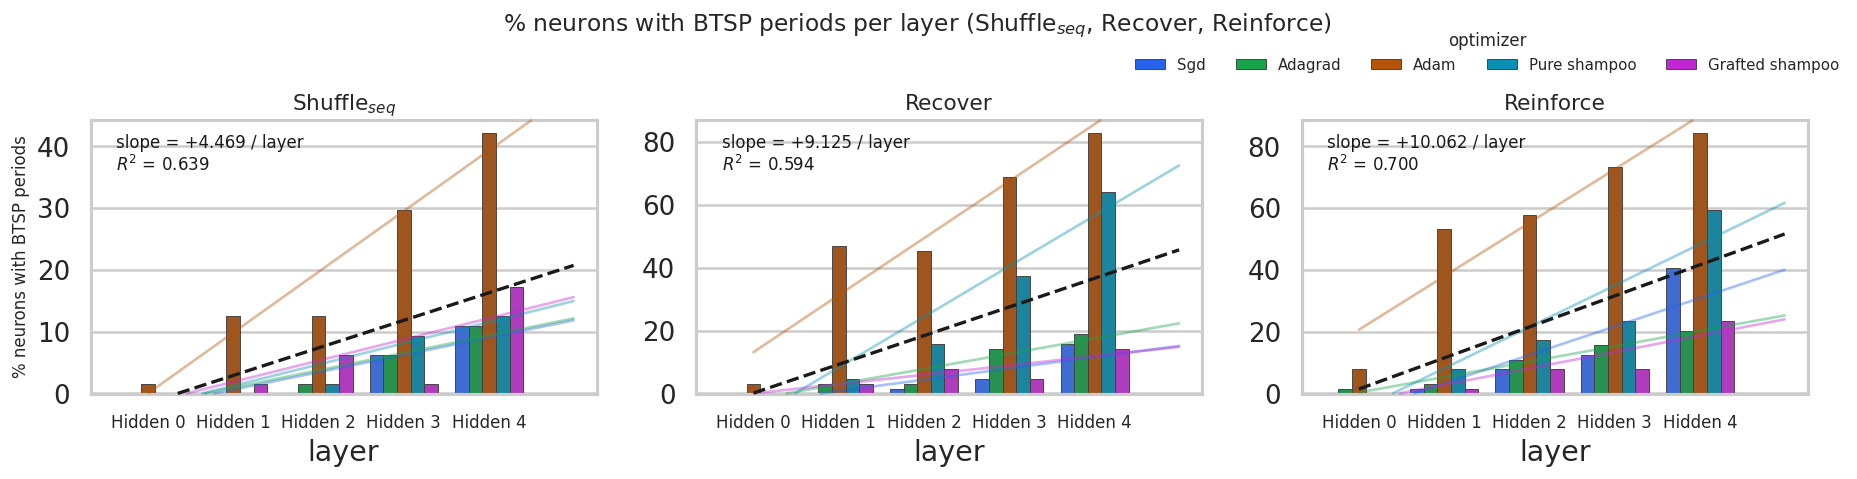

Saved additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf


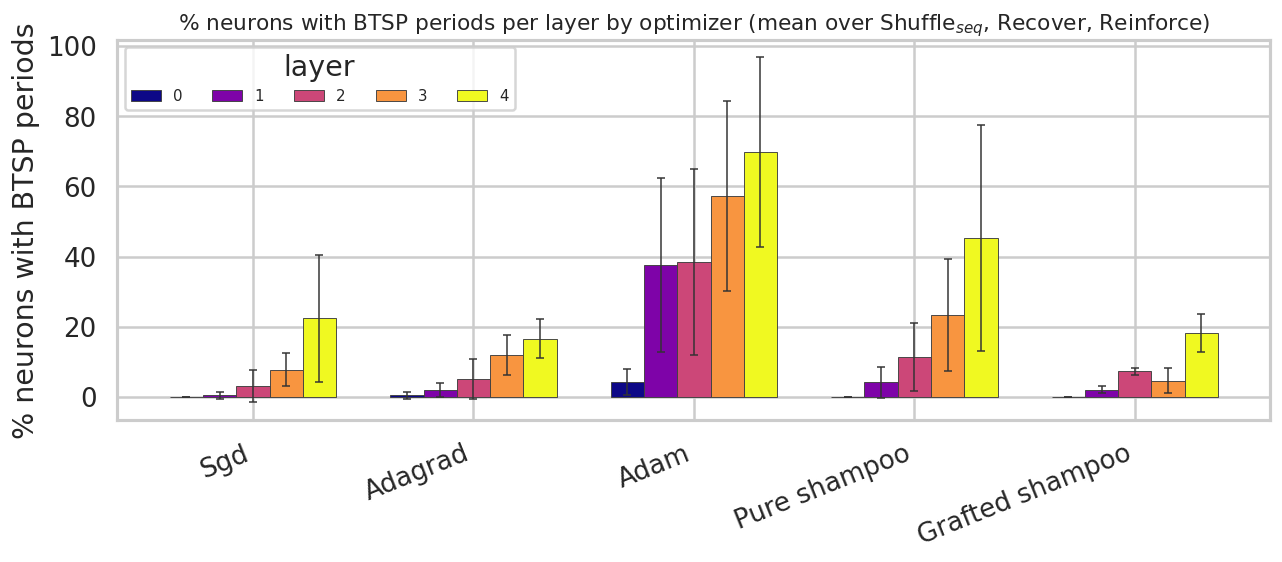

Saved additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf


In [4]:
# BTSP: % neurons per layer with at least one BTSP period (hidden layers only)
df_btsp_pct = build_btsp_neuron_pct_rows(all_results, rename_experiments)
df_btsp_pct = df_btsp_pct[df_btsp_pct["layer_name"].astype(str) != "head"]
print(f"btsp neuron-% rows (per run/layer): {len(df_btsp_pct)}")

_POOL_EXPS = cat2_shuffle_recover_reinforce_labels(LABELS)
_POOL_TITLE_SUFFIX = f"mean over {LABELS.shuffle_seq}, Recover, Reinforce"
per_layer_regressions = {}

if not df_btsp_pct.empty:
	agg_btsp_pct = (
		df_btsp_pct.groupby(["experiment", "layer_name", "optimizer_id"], observed=False)[
			"pct_btsp_neurons"
		]
		.mean()
		.reset_index()
	)
	fig_btsp, _axes_btsp, plotted_btsp = facet_bar_by_experiment_cat12(
		agg_btsp_pct,
		"experiment",
		"pct_btsp_neurons",
		"% neurons with BTSP periods per layer by experiment",
		"% neurons with BTSP periods",
		"additional_btsp_neuron_pct_per_layer_by_experiment.pdf",
		plot_dir=PLOT_DIR,
		sort_experiment_names=_sort_experiment_display_names,
		labels=LABELS,
		show=False,
		save=False,
	)
	if fig_btsp is not None:
		for ax, exp in plotted_btsp:
			sub = agg_btsp_pct[agg_btsp_pct["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "pct_btsp_neurons"
			)
			opt_slopes = overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "pct_btsp_neurons"
			)
			if opt_slopes:
				print(f"\n{exp} — per-optimizer slopes (/layer):")
				for oid, (slope, r2) in opt_slopes.items():
					print(f"  {_opt_display(oid)}: {slope:+.4f}  (R²={r2:.3f})")
				per_layer_regressions[exp] = opt_slopes
				

		fig_btsp.savefig(Path(PLOT_DIR) / "additional_btsp_neuron_pct_per_layer_by_experiment.pdf", bbox_inches="tight")
		plt.show(fig_btsp)
		print("Saved additional_btsp_neuron_pct_per_layer_by_experiment.pdf")

	agg_btsp_cat2 = agg_btsp_pct[agg_btsp_pct["experiment"].astype(str).isin(_POOL_EXPS)]
	fig_btsp_cat2, _axes_cat2, plotted_cat2 = facet_bar_by_experiment_row(
		agg_btsp_cat2,
		"experiment",
		_POOL_EXPS,
		"pct_btsp_neurons",
		f"% neurons with BTSP periods per layer ({LABELS.shuffle_seq}, Recover, Reinforce)",
		"% neurons with BTSP periods",
		"additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf",
		plot_dir=PLOT_DIR,
		show=False,
		save=False,
	)
	if fig_btsp_cat2 is not None:
		for ax, exp in plotted_cat2:
			sub = agg_btsp_cat2[agg_btsp_cat2["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "pct_btsp_neurons"
			)
			overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "pct_btsp_neurons"
			)

		fig_btsp_cat2.savefig(
			Path(PLOT_DIR)
			/ "additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf",
			bbox_inches="tight",
		)
		plt.show(fig_btsp_cat2)
		print("Saved additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf")

	agg_pooled_neuron = pool_btsp_mean_over_experiments(
		agg_btsp_pct, "experiment", _POOL_EXPS, "pct_btsp_neurons"
	)
	if not agg_pooled_neuron.empty:
		plot_btsp_pooled_optimizer_layer_bars(
			agg_pooled_neuron,
			"pct_btsp_neurons",
			"% neurons with BTSP periods",
			f"% neurons with BTSP periods per layer by optimizer ({_POOL_TITLE_SUFFIX})",
			"additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf",
			plot_dir=PLOT_DIR,
			show=True,
			save=True,
		)
		print(
			"Saved additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf"
		)
else:
	print("df_btsp_pct empty — skip BTSP neuron-% plot")



In [5]:
print(r"In \cref{tab:neuron_pct_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.") 
latex_table, latex_best_r2_slope = build_latex_table(
	per_layer_regressions, ref_name="neuron_pct_slopes_r2"
)
print(latex_table)
print()
print(latex_best_r2_slope)


In \cref{tab:neuron_pct_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.
\begin{table}[ht]
\centering
\ra{1.3}
\resizebox{0.95\textwidth}{!}{%
\begin{tabular}{l cc cc cc cc cc cc cc cc}
\toprule
\textbf{Optimizer} & \multicolumn{2}{c}{\textbf{Ctrl. global (\xmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{\{0,1\}}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{all}$}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\xmark PT)}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\cmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{seq}$}} & \multicolumn{2}{c}{\textbf{Recover}} & \multicolumn{2}{c}{\textbf{Reinforce}} \\
\midrule
 & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} \\
\midrule
\textbf{Sgd} & \textbf{+7.8125} & 0.7007 & 0.

score-per-period rows (for layer bar SEM): 2154
score-per-run/layer rows (for across-layer printout): 146
Mean total score across layers (per experiment × optimizer):

Control global (✗PT)
  Sgd: 0.9574
  Adagrad: 1.0453
  Adam: 1.0762
  Pure shampoo: 0.9023
  Grafted shampoo: 1.2208
  experiment mean (all periods): 0.9610

$\text{Shuffle}_{\{0,1\}}$
  Sgd: 1.7676
  Adagrad: 1.4994
  Adam: 1.9333
  Pure shampoo: 1.2874
  Grafted shampoo: 1.9252
  experiment mean (all periods): 1.7026

$\text{Shuffle}_{all}$
  Sgd: 0.9547
  Adagrad: 0.9557
  Adam: 1.0895
  Pure shampoo: 1.0784
  Grafted shampoo: 1.0167
  experiment mean (all periods): 0.9693

Control sequential (✗PT)
  Sgd: 1.6174
  Adagrad: 1.7991
  Adam: 1.4014
  Pure shampoo: 1.3435
  Grafted shampoo: 1.3092
  experiment mean (all periods): 1.4155

Control sequential (✔PT)
  Sgd: 1.4069
  Adagrad: 1.1788
  Adam: 1.4263
  Pure shampoo: 1.0638
  Grafted shampoo: 1.4033
  experiment mean (all periods): 1.2276

$\text{Shuffle}_{seq}$
  S

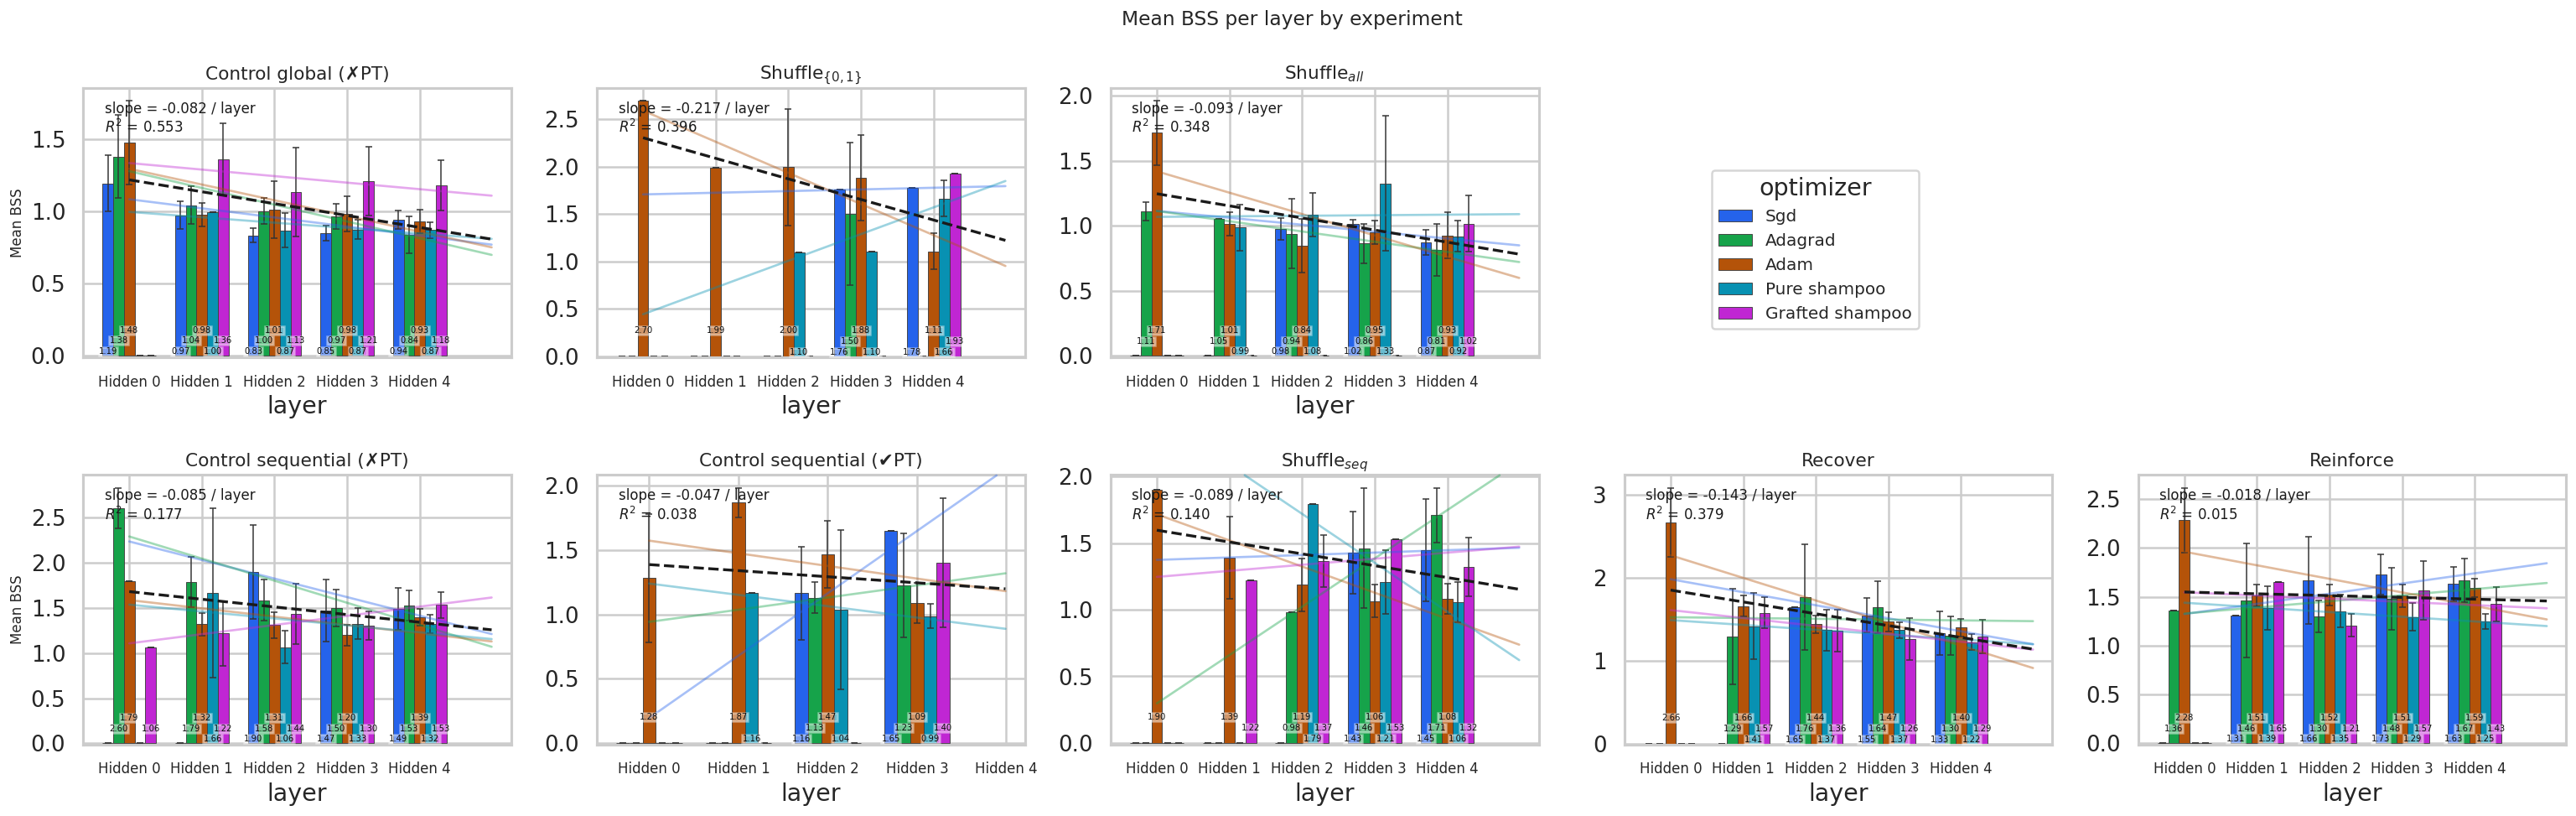

Saved additional_mean_score_per_layer_by_experiment.pdf


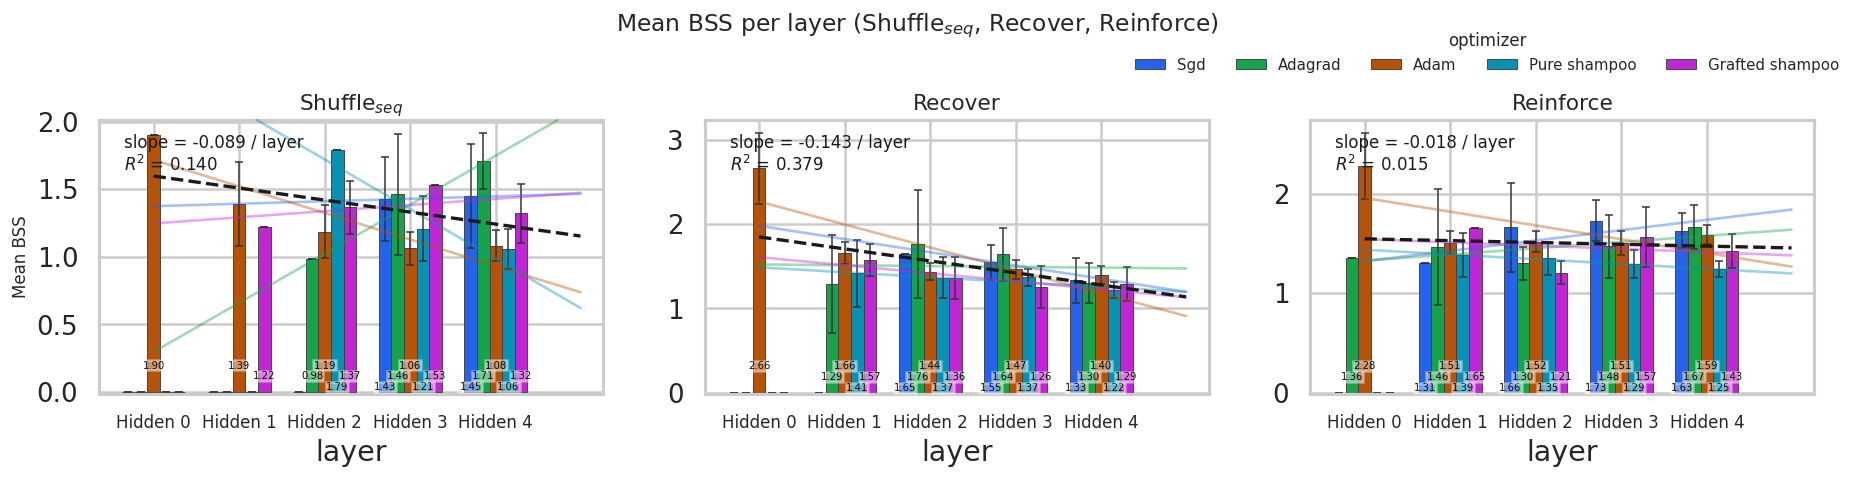

Saved additional_mean_score_per_layer_shuffle_recover_reinforce.pdf


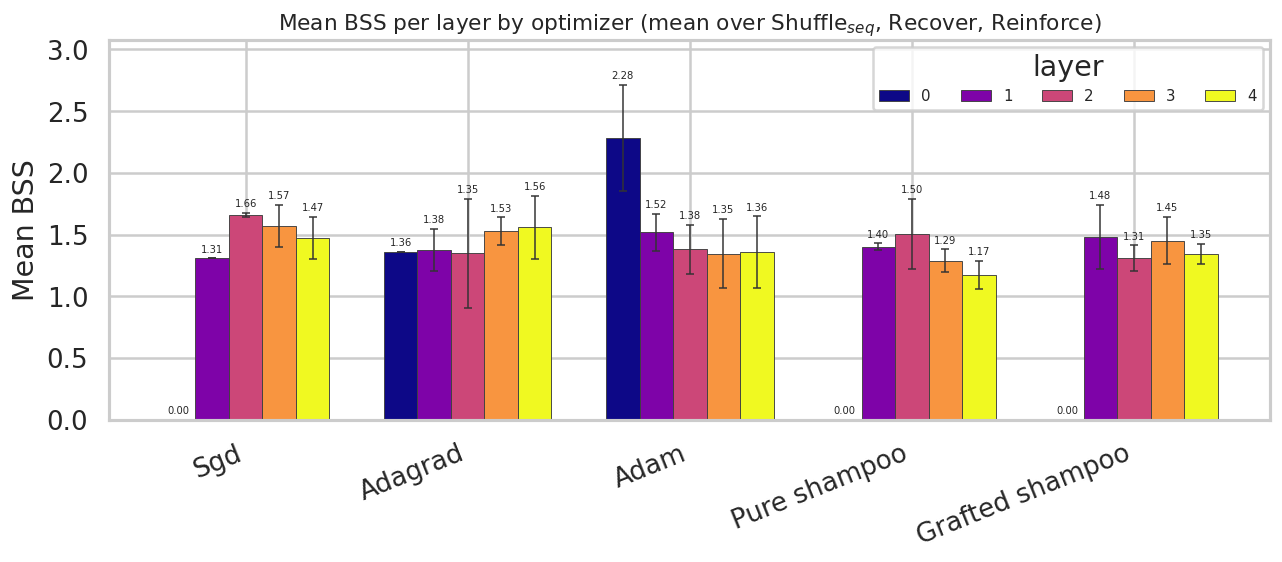

Saved additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf


In [6]:
# Score per layer: mean total_score across periods (hidden layers only), ±1.96 SEM
df_score_periods = build_layer_period_score_rows(all_results, rename_experiments)
df_score_periods = df_score_periods[df_score_periods["layer_name"].astype(str) != "head"]
print(f"score-per-period rows (for layer bar SEM): {len(df_score_periods)}")

df_score_layer = build_layer_mean_score_rows(all_results, rename_experiments)
df_score_layer = df_score_layer[df_score_layer["layer_name"].astype(str) != "head"]
print(f"score-per-run/layer rows (for across-layer printout): {len(df_score_layer)}")

print_mean_score_across_layers(
	df_score_layer,
	labels=LABELS,
	period_df=df_score_periods,
	sort_experiment_names=_sort_experiment_display_names,
)

_POOL_EXPS_SCORE = cat2_shuffle_recover_reinforce_labels(LABELS)
_POOL_TITLE_SUFFIX_SCORE = f"mean over {LABELS.shuffle_seq}, Recover, Reinforce"
score_per_layer_regressions = {}

if not df_score_periods.empty:
	agg_score = aggregate_layer_metric_mean_sem(
		df_score_periods,
		["experiment", "layer_name", "optimizer_id"],
		"total_score",
	)
	fig_score, _axes_score, plotted_score = facet_bar_by_experiment_cat12(
		agg_score,
		"experiment",
		"total_score",
		"Mean BSS per layer by experiment",
		"Mean BSS",
		"additional_mean_score_per_layer_by_experiment.pdf",
		plot_dir=PLOT_DIR,
		sort_experiment_names=_sort_experiment_display_names,
		labels=LABELS,
		sem_col="sem",
		annotate_bars=True,
		annotate_bars_inside=True,
		show=False,
		save=False,
	)
	if fig_score is not None:
		for ax, exp in plotted_score:
			sub = agg_score[agg_score["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
			score_opt_slopes = overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
			score_per_layer_regressions[exp] = score_opt_slopes
		
		fig_score.savefig(
			Path(PLOT_DIR) / "additional_mean_score_per_layer_by_experiment.pdf",
			bbox_inches="tight",
		)
		plt.show(fig_score)
		print("Saved additional_mean_score_per_layer_by_experiment.pdf")

	agg_score_cat2 = agg_score[agg_score["experiment"].astype(str).isin(_POOL_EXPS_SCORE)]
	fig_score_cat2, _axes_score_cat2, plotted_score_cat2 = facet_bar_by_experiment_row(
		agg_score_cat2,
		"experiment",
		_POOL_EXPS_SCORE,
		"total_score",
		f"Mean BSS per layer ({LABELS.shuffle_seq}, Recover, Reinforce)",
		"Mean BSS",
		"additional_mean_score_per_layer_shuffle_recover_reinforce.pdf",
		plot_dir=PLOT_DIR,
		sem_col="sem",
		annotate_bars=True,
		annotate_bars_inside=True,
		show=False,
		save=False,
	)
	if fig_score_cat2 is not None:
		for ax, exp in plotted_score_cat2:
			sub = agg_score_cat2[agg_score_cat2["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
			overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
		fig_score_cat2.savefig(
			Path(PLOT_DIR)
			/ "additional_mean_score_per_layer_shuffle_recover_reinforce.pdf",
			bbox_inches="tight",
		)
		plt.show(fig_score_cat2)
		print("Saved additional_mean_score_per_layer_shuffle_recover_reinforce.pdf")

	agg_pooled_score = pool_btsp_mean_over_experiments(
		agg_score, "experiment", _POOL_EXPS_SCORE, "total_score"
	)
	if not agg_pooled_score.empty:
		plot_btsp_pooled_optimizer_layer_bars(
			agg_pooled_score,
			"total_score",
			"Mean BSS",
			f"Mean BSS per layer by optimizer ({_POOL_TITLE_SUFFIX_SCORE})",
			"additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf",
			plot_dir=PLOT_DIR,
			annotate_bars=True,
			annotate_bars_inside=False,
			show=True,
			save=True,
		)
		print(
			"Saved additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf"
		)
else:
	print("df_score_periods empty — skip score-per-layer plots")


In [7]:
print(r"In \cref{tab:bss_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.") 
score_latex_table, score_latex_best_r2_slope = build_latex_table(
	score_per_layer_regressions, ref_name="bss_slopes_r2"
)
print(score_latex_table)
print()
print(score_latex_best_r2_slope)


In \cref{tab:bss_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.
\begin{table}[ht]
\centering
\ra{1.3}
\resizebox{0.95\textwidth}{!}{%
\begin{tabular}{l cc cc cc cc cc cc cc cc}
\toprule
\textbf{Optimizer} & \multicolumn{2}{c}{\textbf{Ctrl. global (\xmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{\{0,1\}}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{all}$}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\xmark PT)}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\cmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{seq}$}} & \multicolumn{2}{c}{\textbf{Recover}} & \multicolumn{2}{c}{\textbf{Reinforce}} \\
\midrule
 & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} \\
\midrule
\textbf{Sgd} & -0.0630 & 0.4766 & 0.0175 & \textbf{{

btsp cumulative segment rows (model/optimizer/layer/run): 750


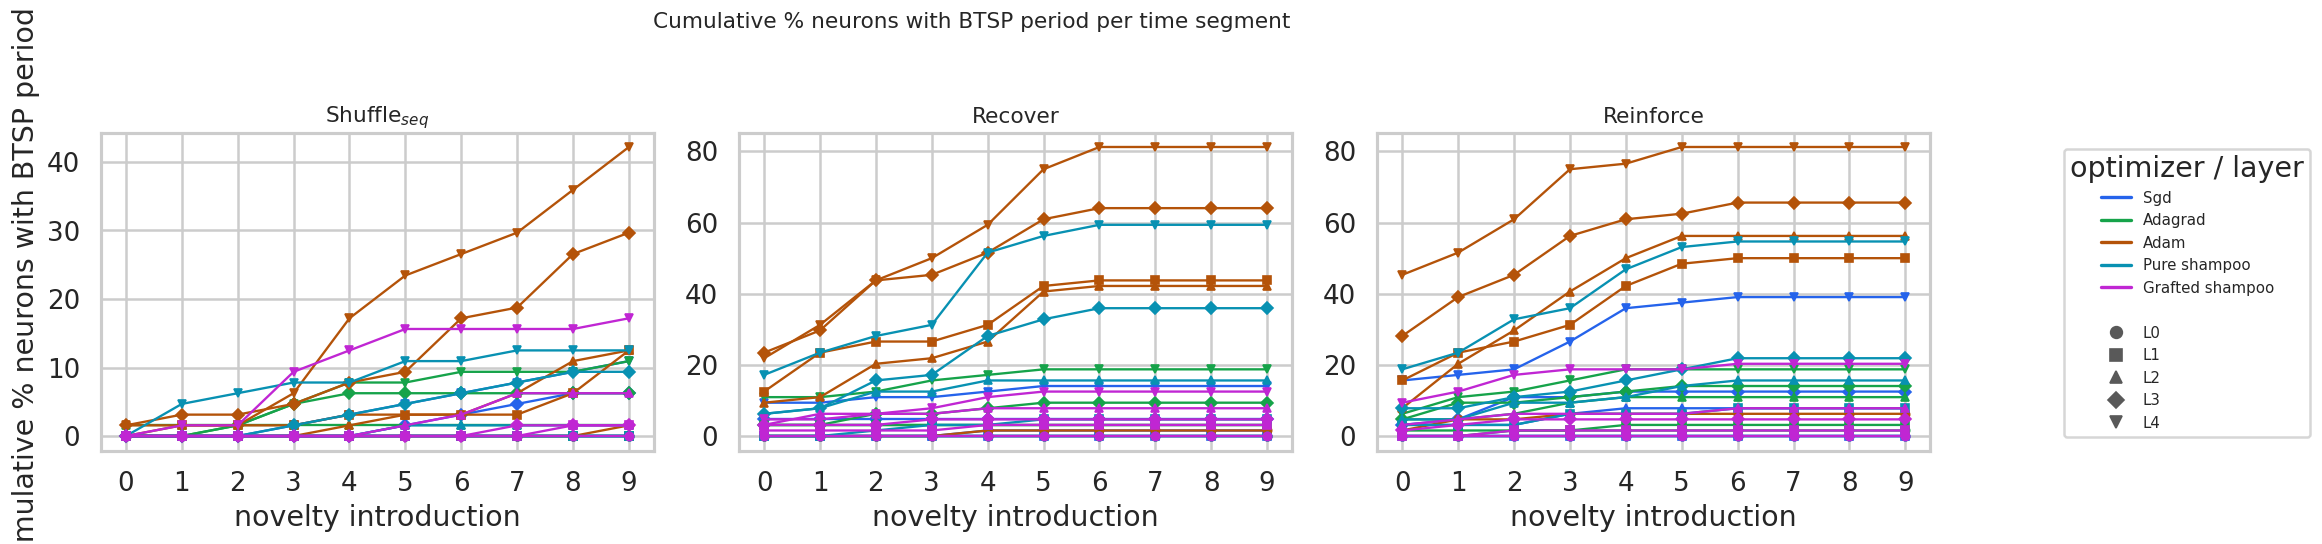

Saved additional_btsp_neuron_pct_cumulative_segments.pdf


In [8]:
# Cumulative BTSP neuron % across runs
# Each x-tick = one experimental run (different digit / digit-pair scenario)
# Shuffle: 10 runs × 100 post-novelty iters; Recover / Reinforce: 10 runs × 300 iters
# y = running % of unique neurons seen up to that run (running union, no double-counting)
df_btsp_seg = build_btsp_neuron_pct_segment_rows(all_results, rename_experiments, LABELS)
df_btsp_seg = df_btsp_seg[df_btsp_seg["layer_name"].astype(str) != "head"]
print(f"btsp cumulative segment rows (model/optimizer/layer/run): {len(df_btsp_seg)}")

if not df_btsp_seg.empty:
	plot_btsp_neuron_pct_segment_trajectories(
		df_btsp_seg,
		labels=LABELS,
		plot_dir=PLOT_DIR,
		show=True,
		save=True,
	)
	print("Saved additional_btsp_neuron_pct_cumulative_segments.pdf")
else:
	print("df_btsp_seg empty — skip cumulative segment trajectory plot")

period metric rows: 2154


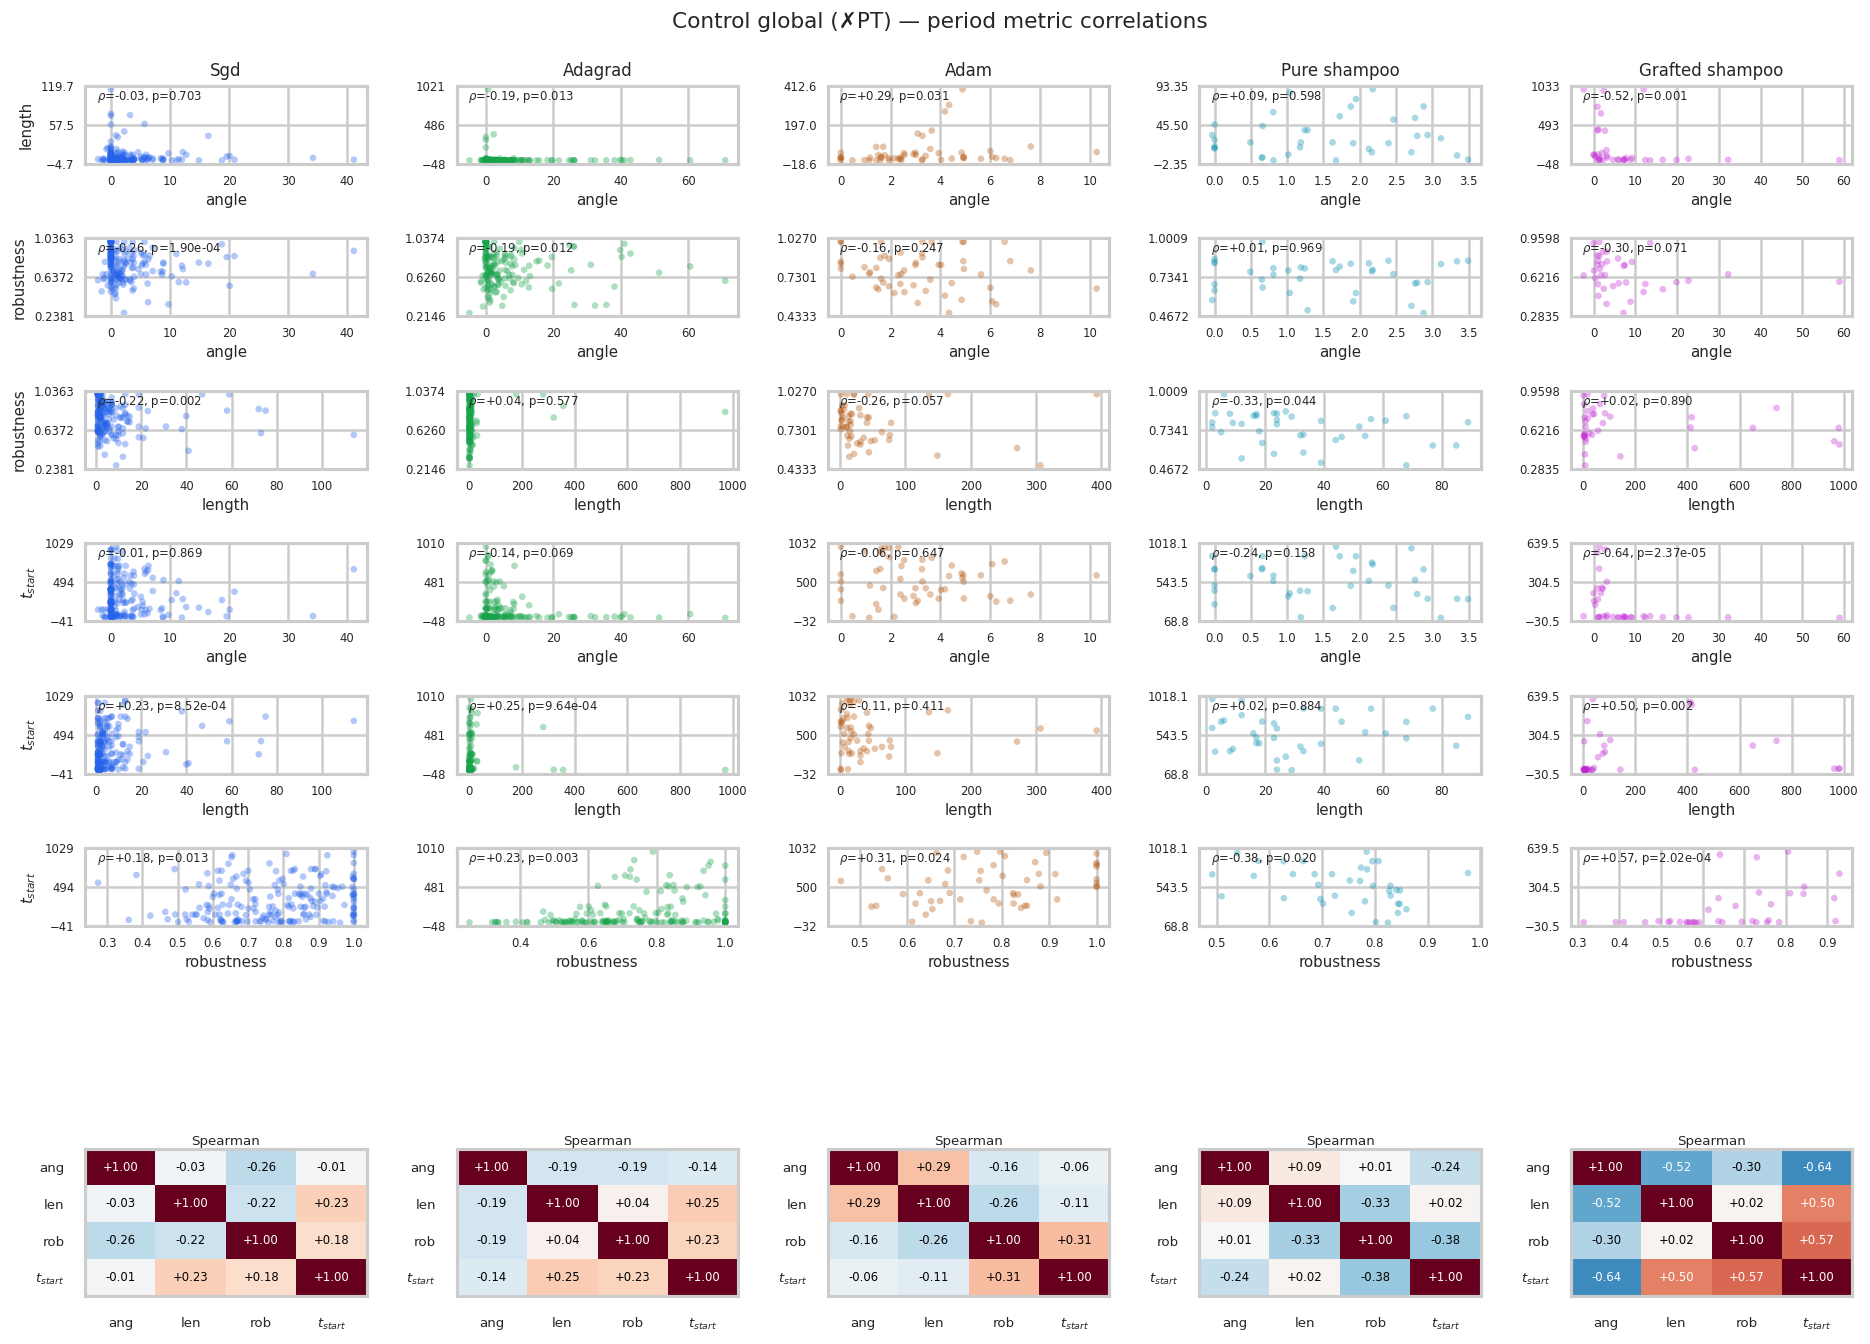

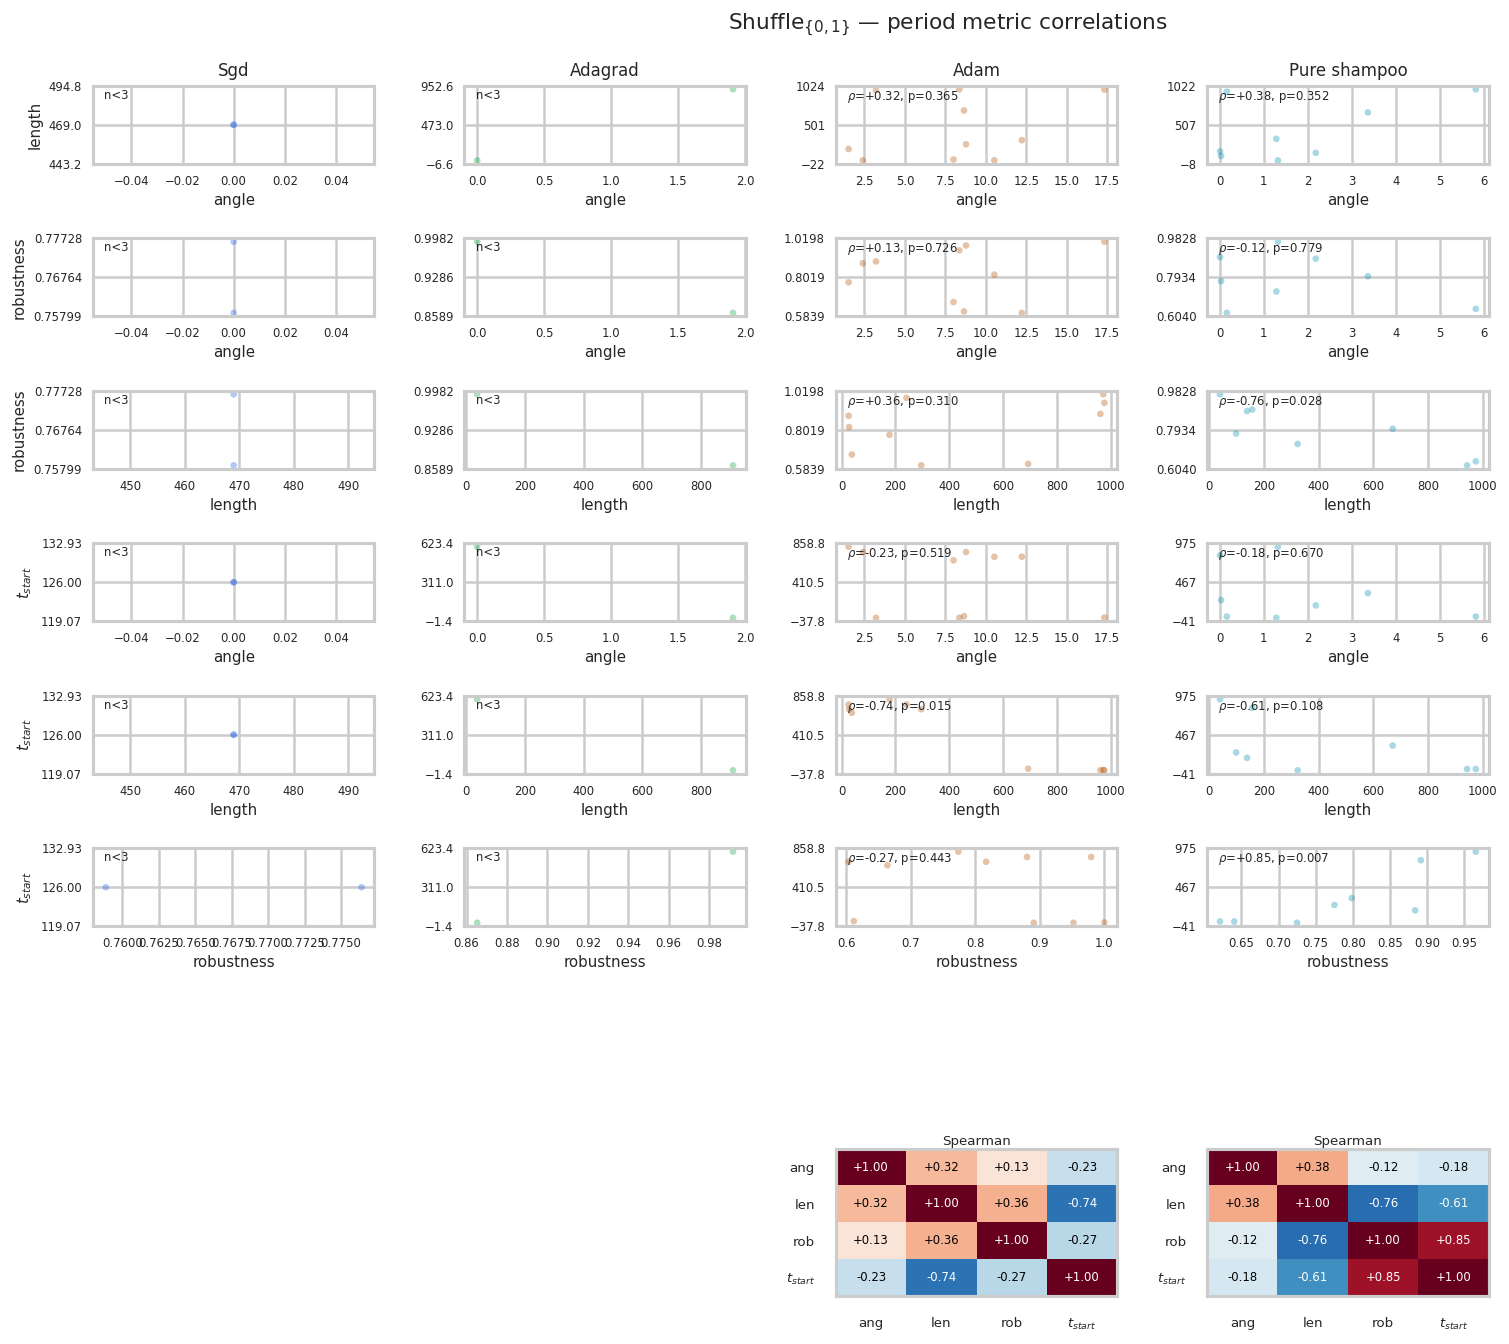

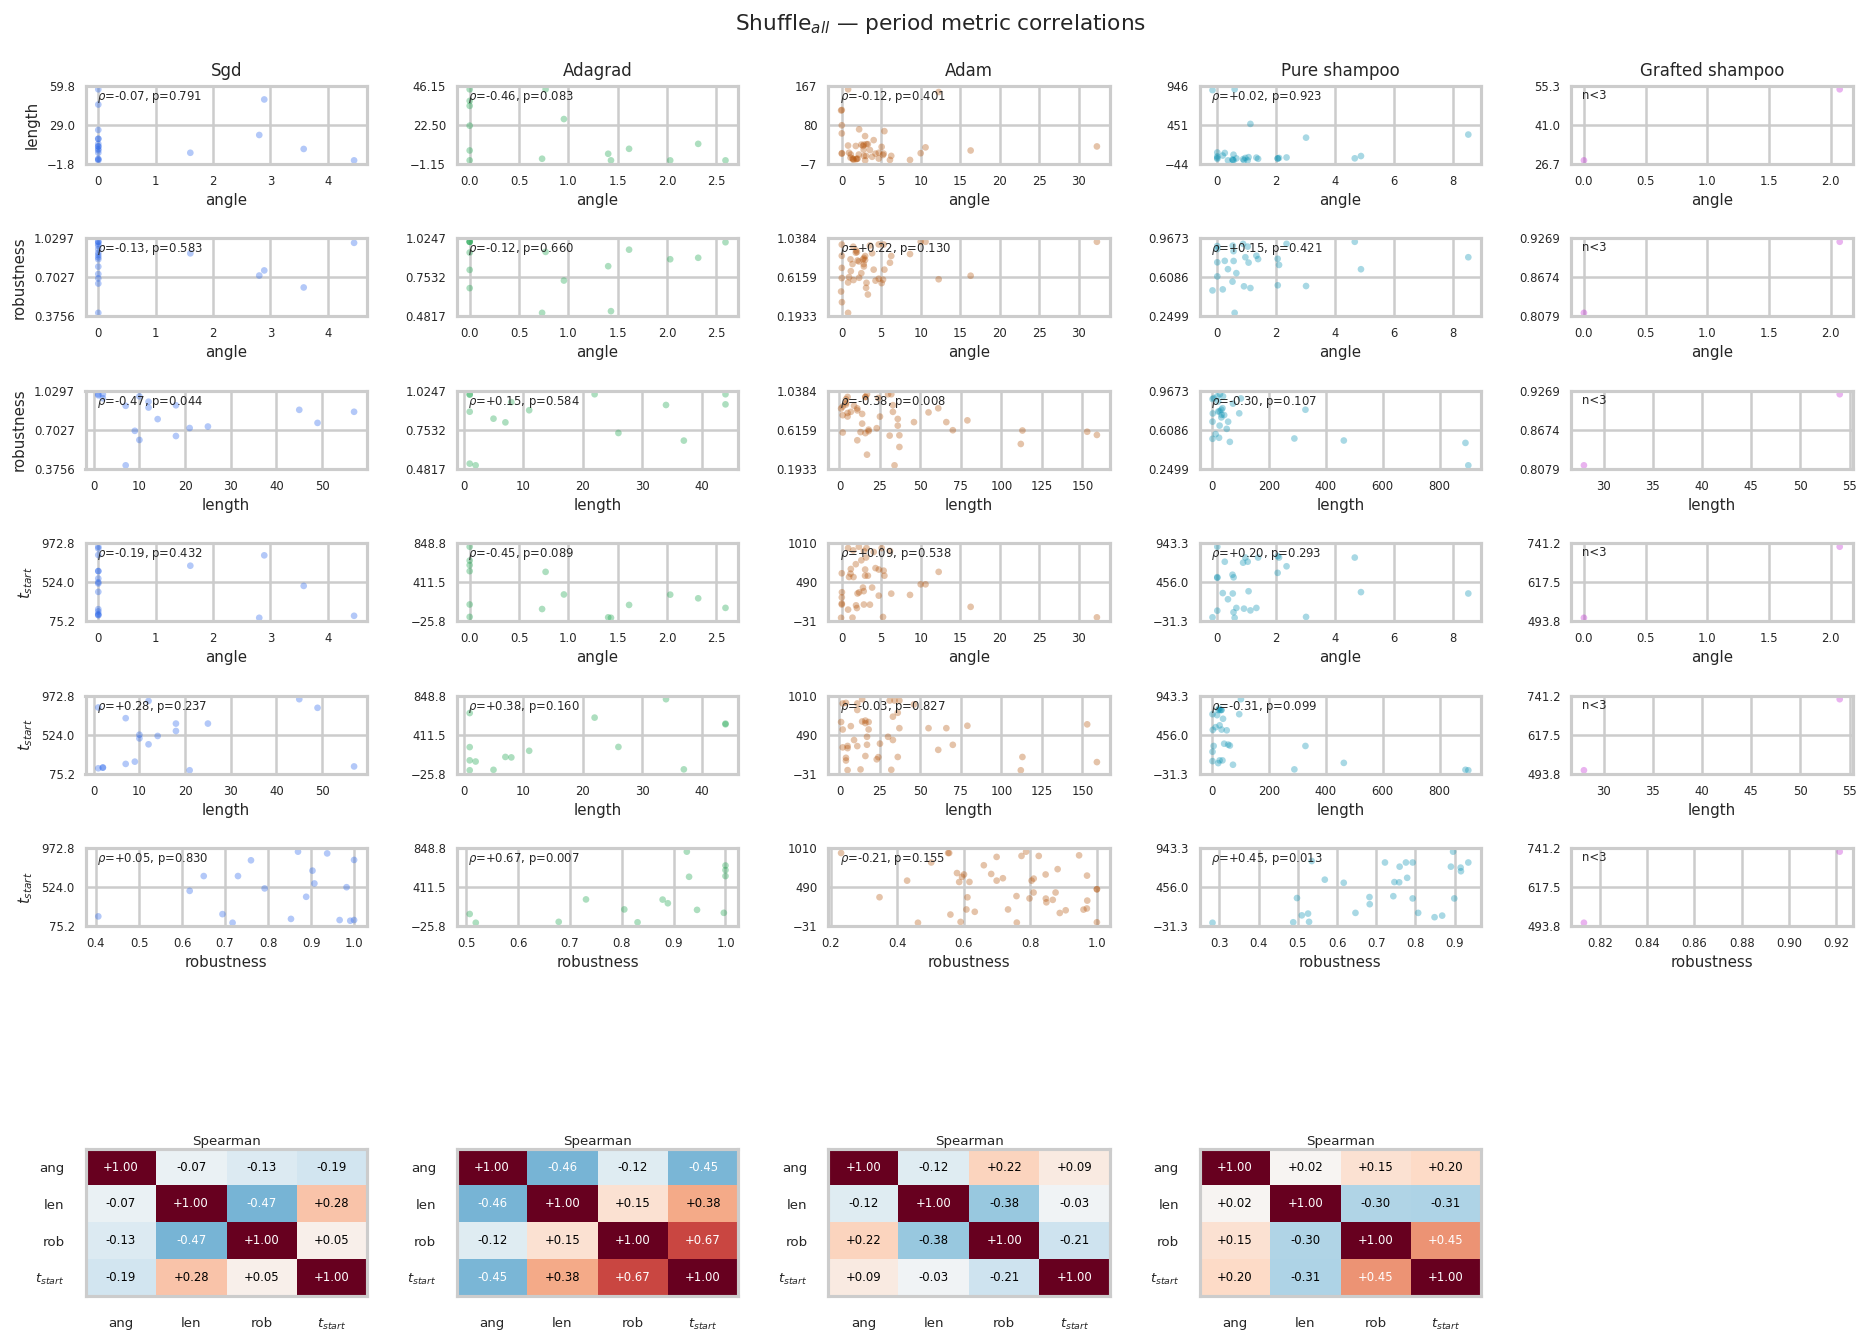

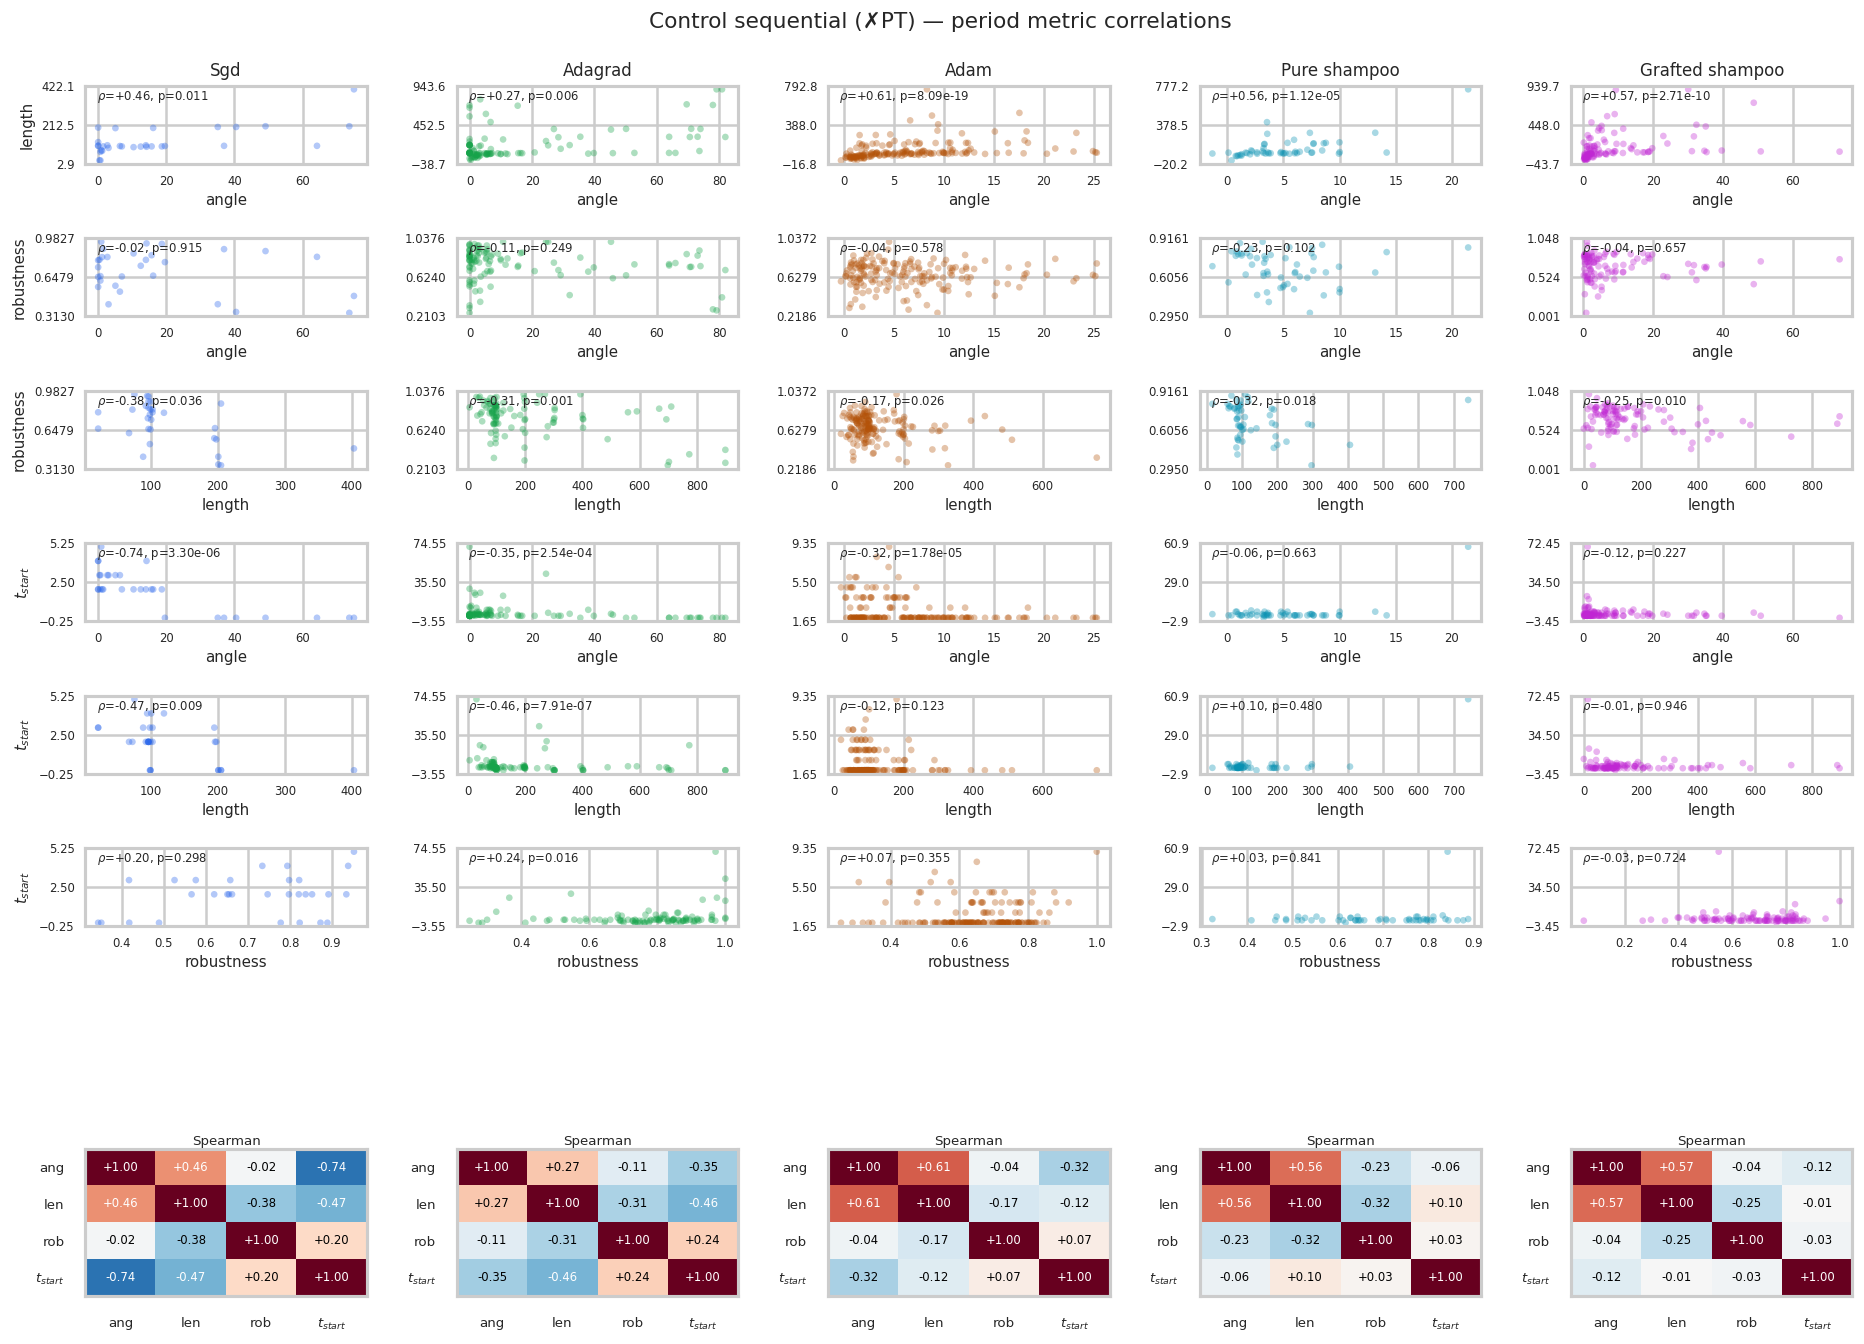

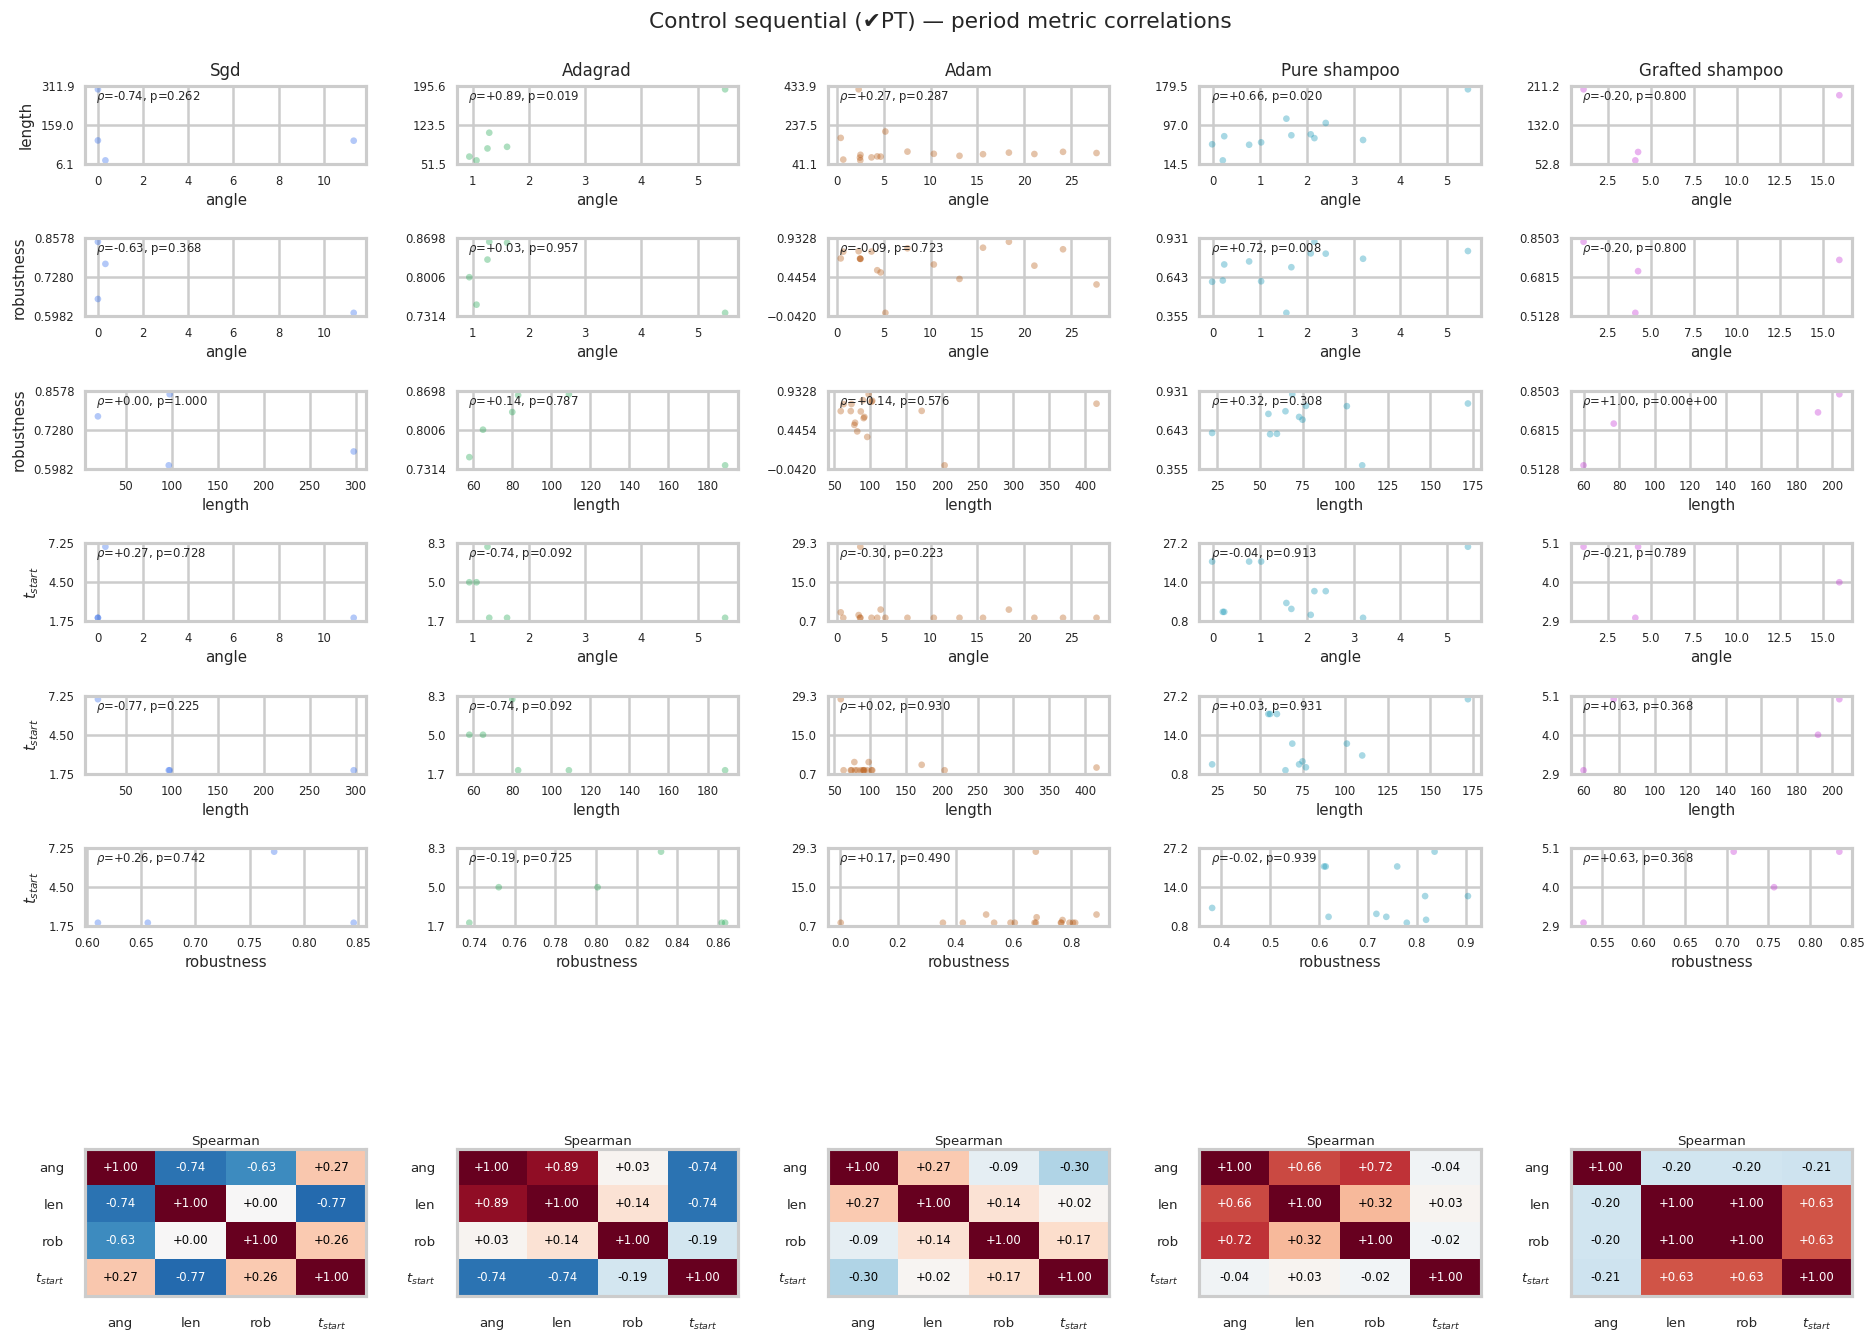

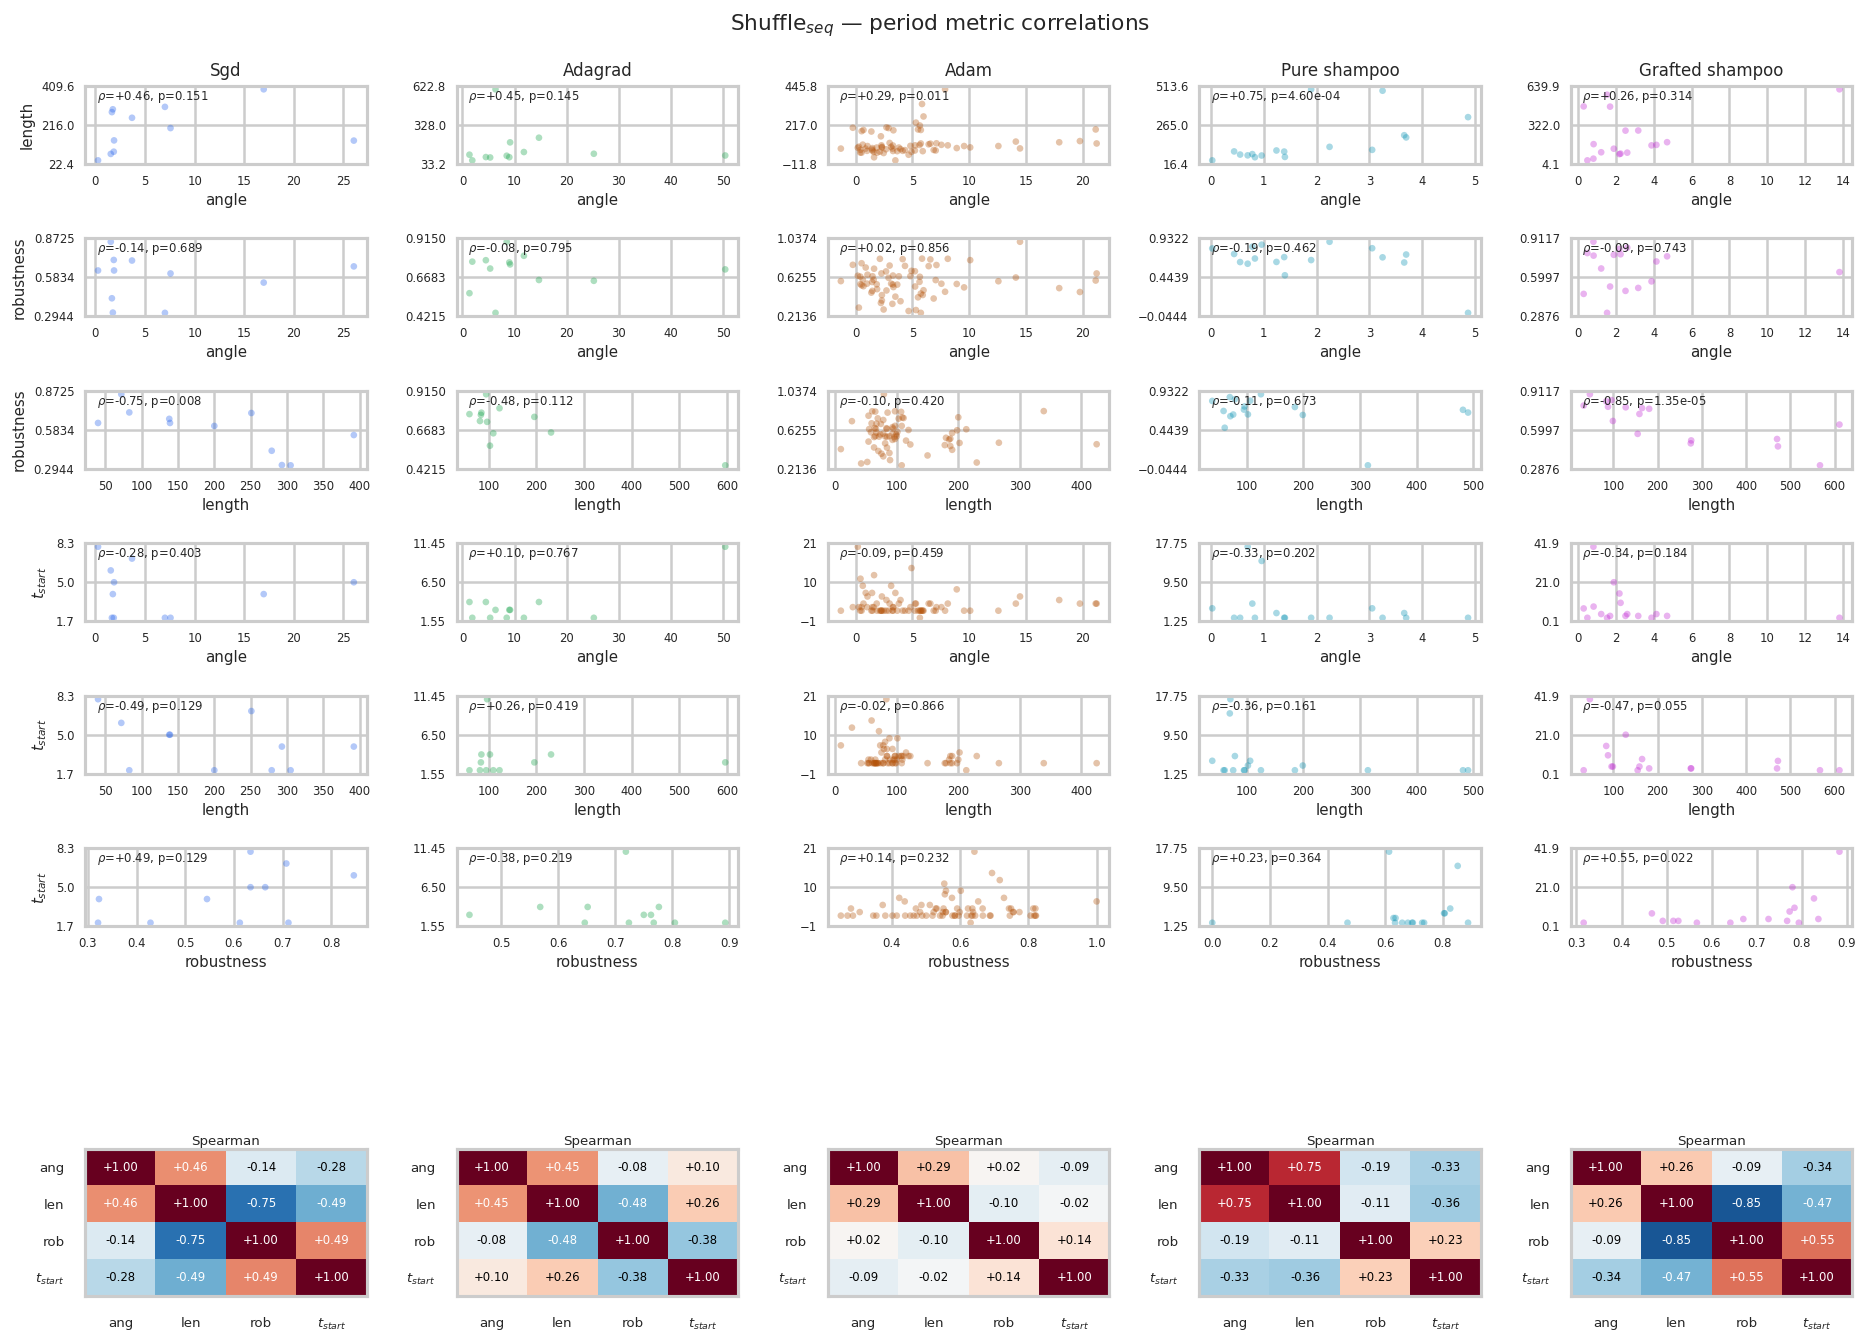

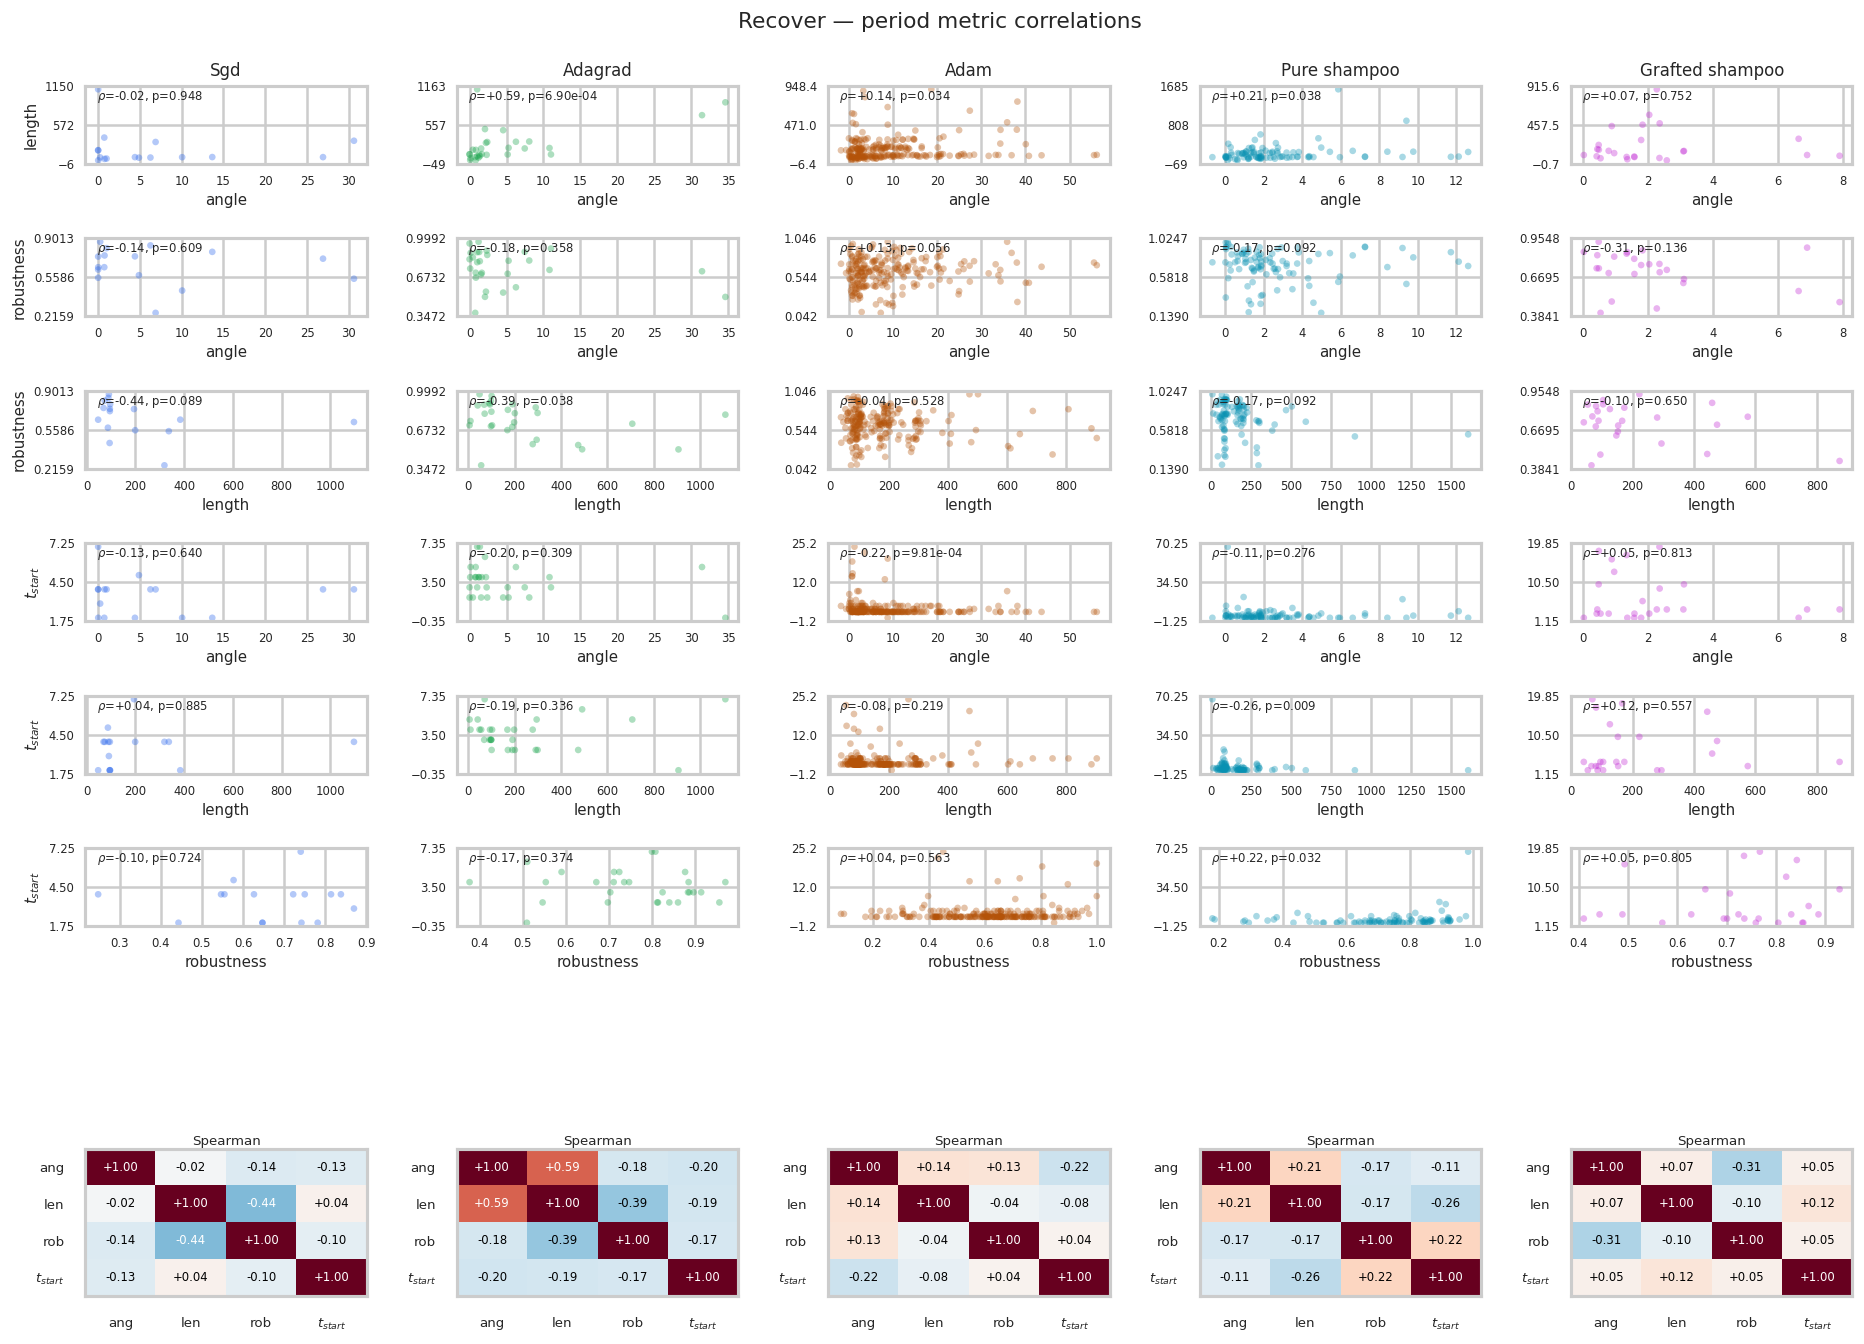

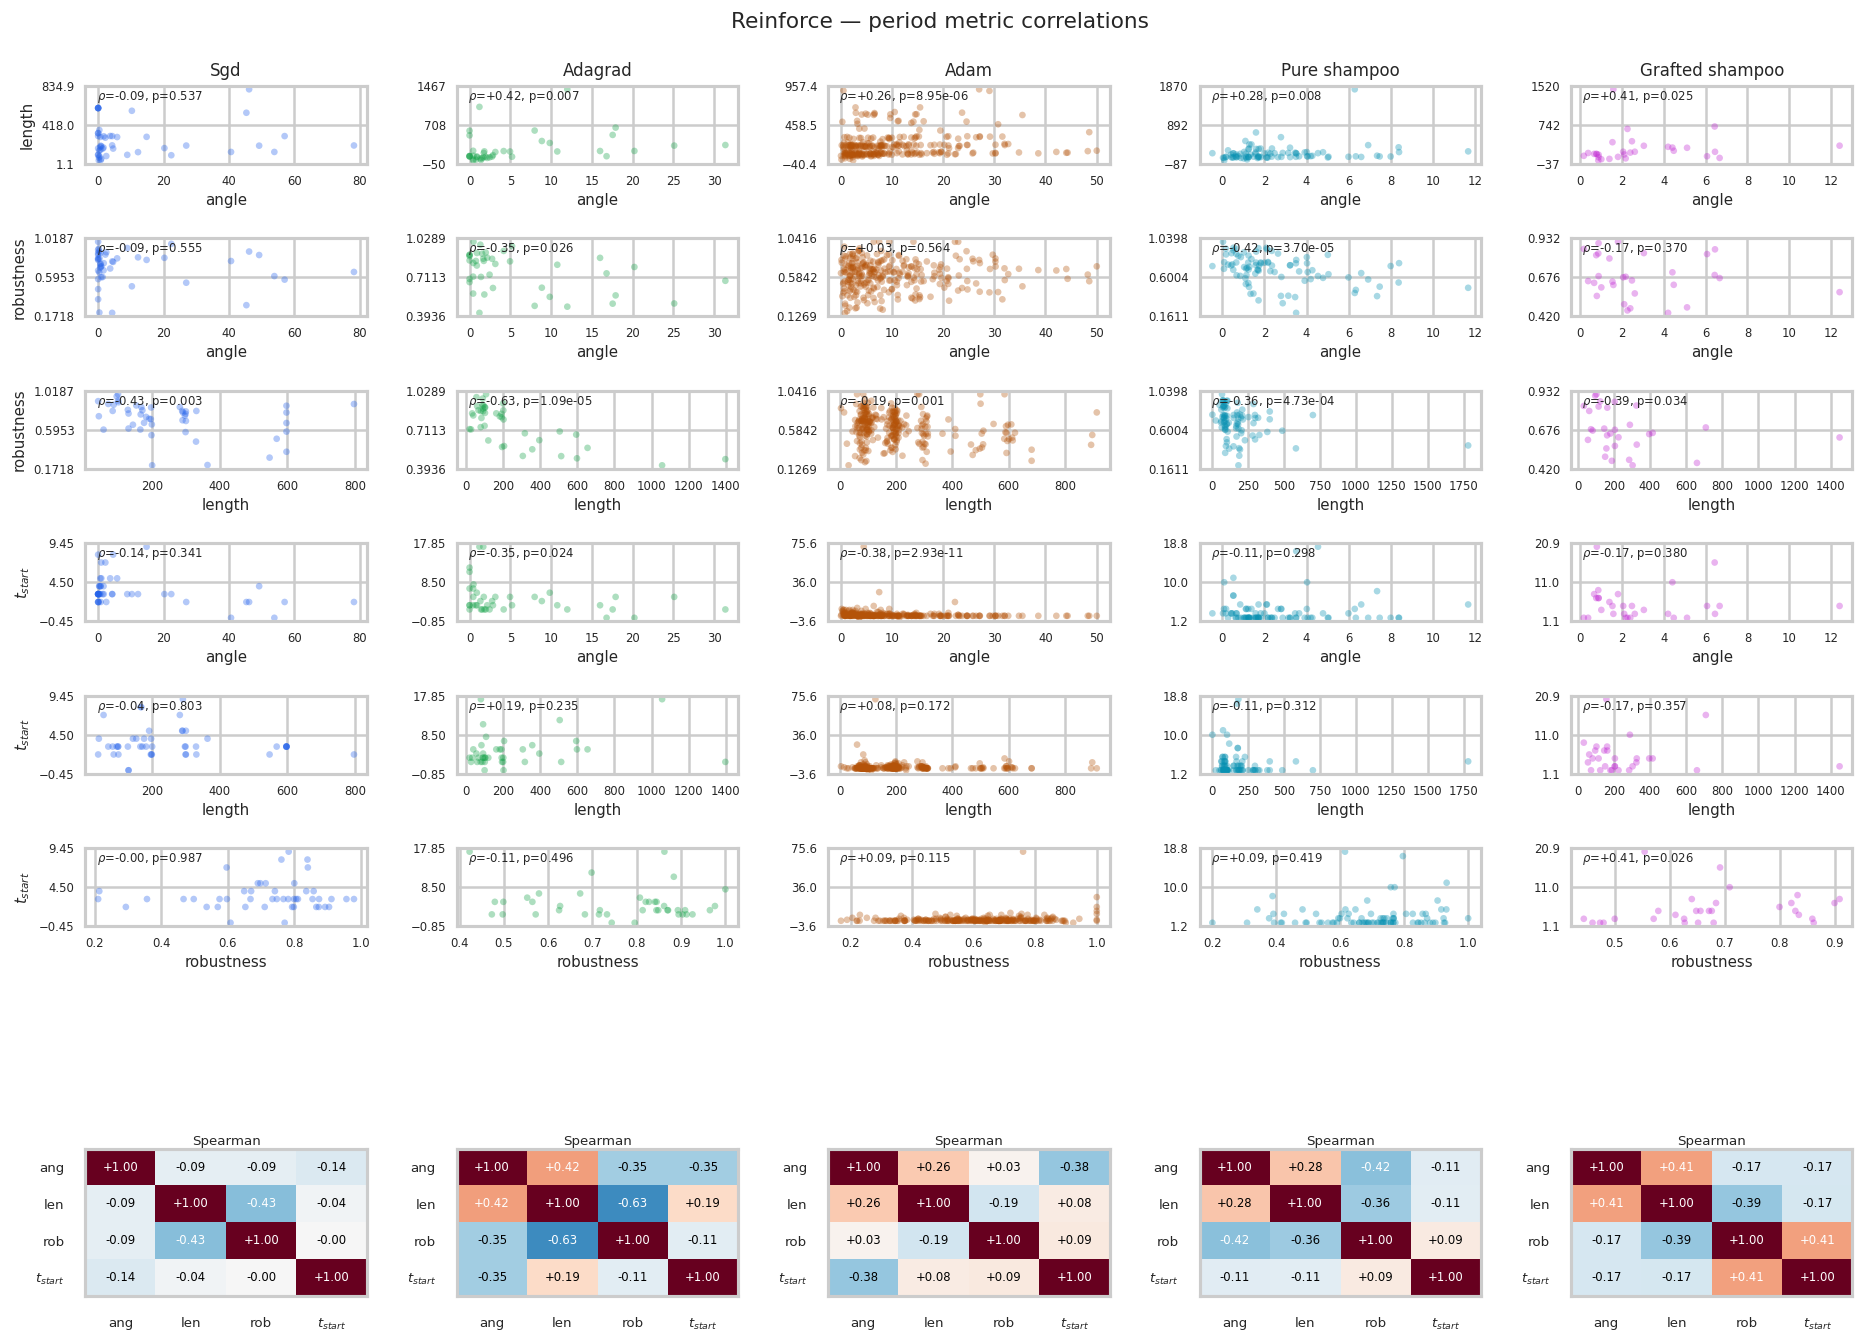

Saved additional_corr_<experiment>.pdf per experiment


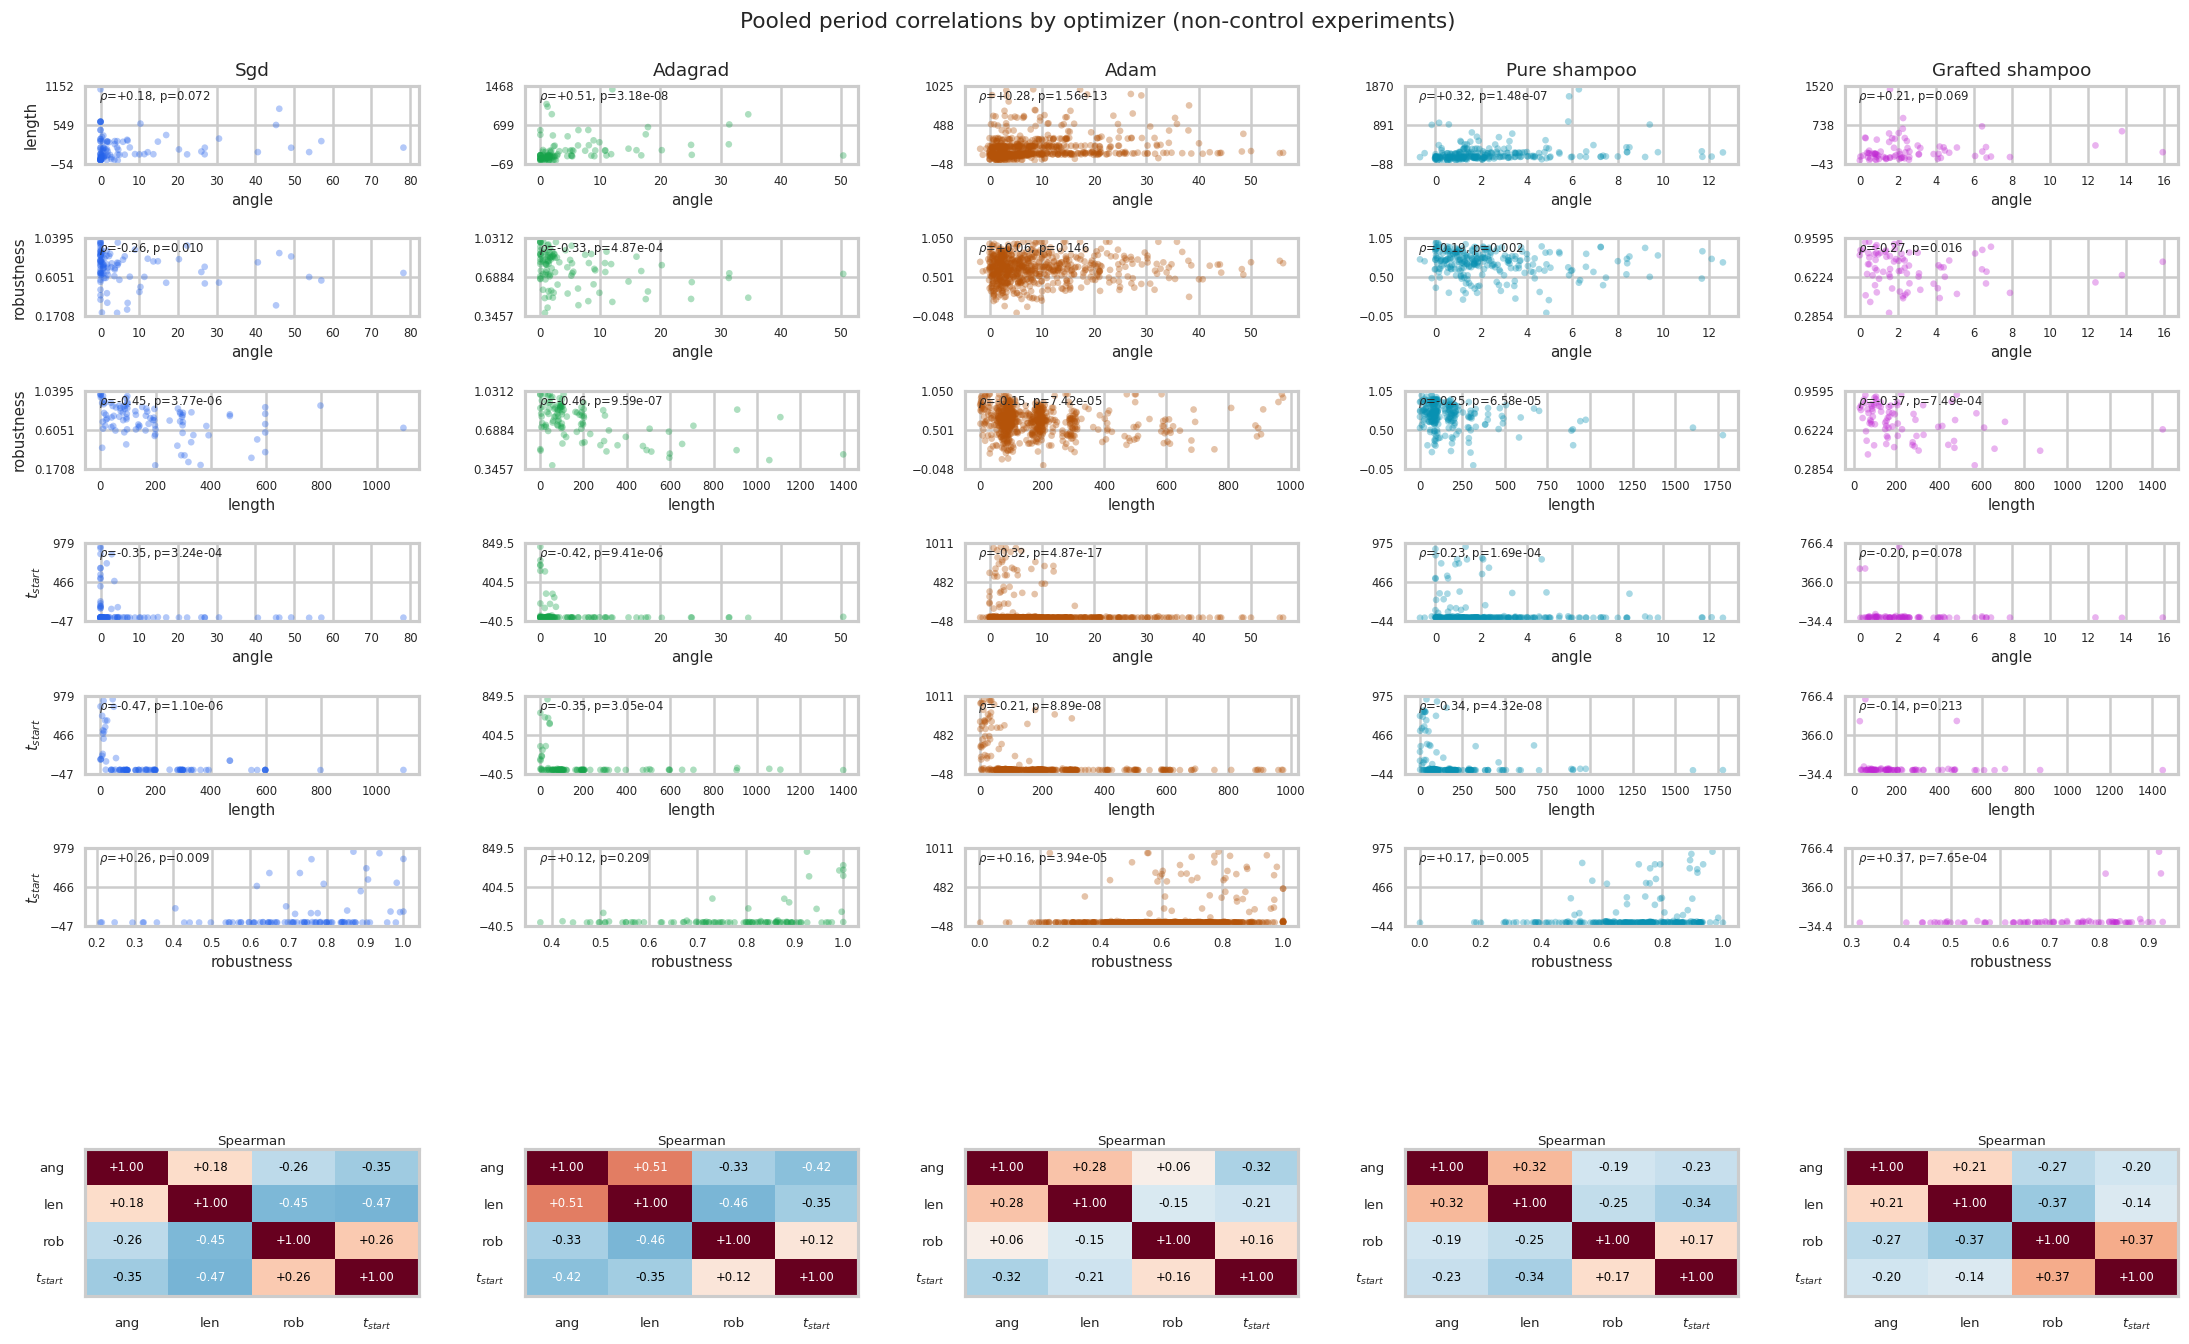

Saved additional_corr_pooled_by_optimizer_no_controls.pdf


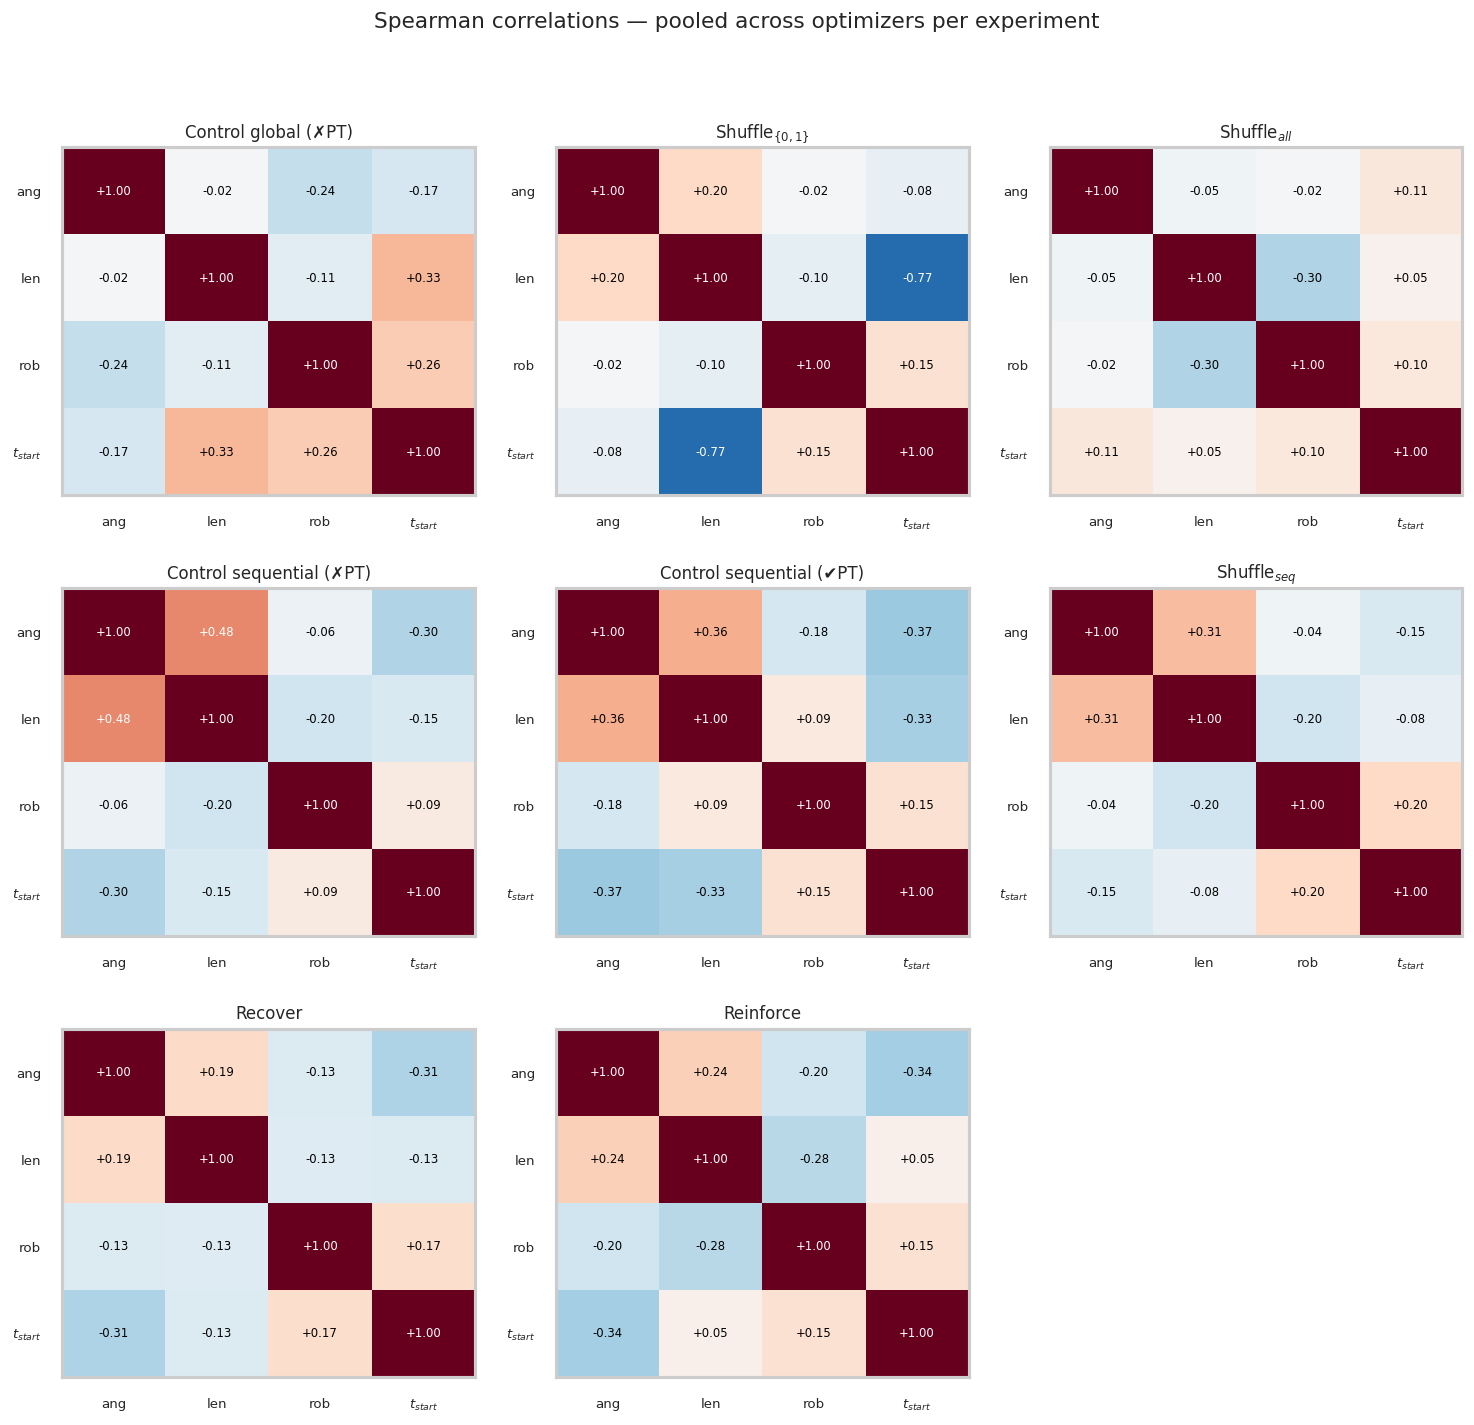

Saved additional_corr_matrix_by_experiment.pdf


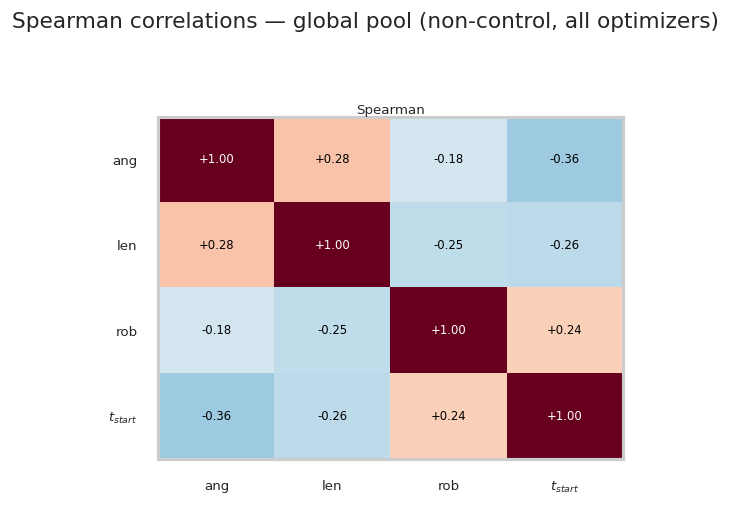

Saved additional_corr_matrix_global_pool.pdf


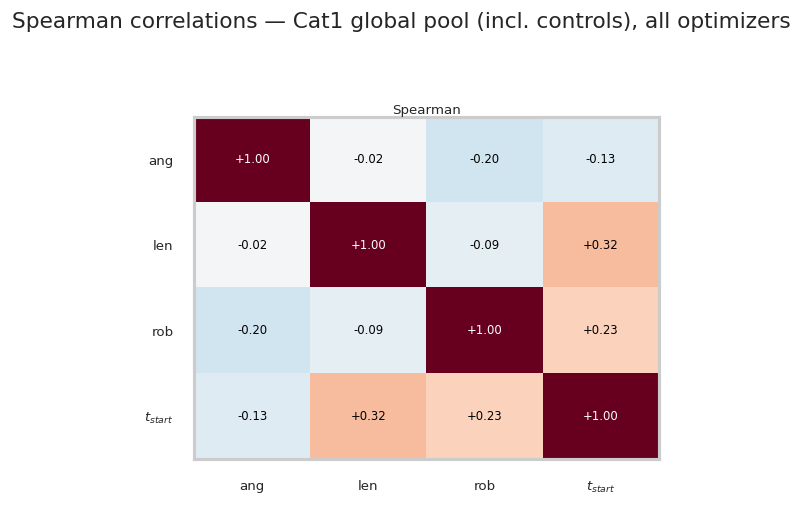

Saved additional_corr_matrix_global_pool_cat1.pdf


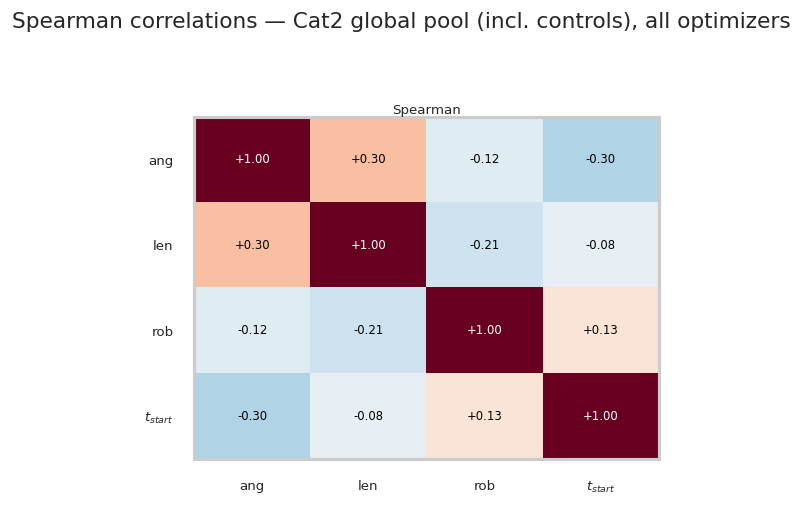

Saved additional_corr_matrix_global_pool_cat2.pdf


In [26]:
# Correlations: angle, length, robustness, t_start (offset from novelty; cat1 = trial_start+PMA, cat2 = PMA)
df_period_metrics = build_period_metrics_df(all_results, rename_experiments)
print(f"period metric rows: {len(df_period_metrics)}")

if not df_period_metrics.empty:
	df_period_copy = df_period_metrics.copy()
	df_period_copy["t_start_inv"] = - df_period_copy["t_start"]
	_corr_matrix_kw = dict(
		plot_dir=PLOT_DIR,
		sort_experiment_names=_sort_experiment_display_names,
		corr_mat_cols=_CORR_MAT_COLS,
		corr_mat_labels=_CORR_MAT_LABELS,
		show=True,
	)
	_corr_scatter_kw = dict(_corr_matrix_kw, corr_pairs=_CORR_PAIRS)
	plot_correlations_per_experiment(df_period_copy, **_corr_scatter_kw)
	print("Saved additional_corr_<experiment>.pdf per experiment")
	plot_correlations_pooled_by_optimizer(
		df_period_copy,
		labels=LABELS,
		**_corr_scatter_kw,
	)
	print("Saved additional_corr_pooled_by_optimizer_no_controls.pdf")
	plot_correlation_matrices_pooled_by_experiment(df_period_copy, **_corr_matrix_kw)
	print("Saved additional_corr_matrix_by_experiment.pdf")
	plot_correlation_matrix_global_pool(
		df_period_copy,
		plot_dir=PLOT_DIR,
		labels=LABELS,
		corr_mat_cols=_CORR_MAT_COLS,
		corr_mat_labels=_CORR_MAT_LABELS,
		show=True,
	)
	print("Saved additional_corr_matrix_global_pool.pdf")
	plot_correlation_matrix_global_pool(
		df_period_copy,
		plot_dir=PLOT_DIR,
		labels=LABELS,
		corr_mat_cols=_CORR_MAT_COLS,
		corr_mat_labels=_CORR_MAT_LABELS,
		show=True,
		category="cat1",
		exclude_controls=False,
	)
	print("Saved additional_corr_matrix_global_pool_cat1.pdf")
	plot_correlation_matrix_global_pool(
		df_period_copy,
		plot_dir=PLOT_DIR,
		labels=LABELS,
		corr_mat_cols=_CORR_MAT_COLS,
		corr_mat_labels=_CORR_MAT_LABELS,
		show=True,
		category="cat2",
		exclude_controls=False,
	)
	print("Saved additional_corr_matrix_global_pool_cat2.pdf")
else:
	print("df_period_metrics empty — skip correlation plots")


score-per-period rows (for layer bar SEM): 2154
score-per-run/layer rows (for across-layer printout): 146
Mean total score across layers (per experiment × optimizer):

Control global (✗PT)
  Sgd: 0.9574
  Adagrad: 1.0453
  Adam: 1.0762
  Pure shampoo: 0.9023
  Grafted shampoo: 1.2208
  experiment mean (all periods): 0.9610

$\text{Shuffle}_{\{0,1\}}$
  Sgd: 1.7676
  Adagrad: 1.4994
  Adam: 1.9333
  Pure shampoo: 1.2874
  Grafted shampoo: 1.9252
  experiment mean (all periods): 1.7026

$\text{Shuffle}_{all}$
  Sgd: 0.9547
  Adagrad: 0.9557
  Adam: 1.0895
  Pure shampoo: 1.0784
  Grafted shampoo: 1.0167
  experiment mean (all periods): 0.9693

Control sequential (✗PT)
  Sgd: 1.6174
  Adagrad: 1.7991
  Adam: 1.4014
  Pure shampoo: 1.3435
  Grafted shampoo: 1.3092
  experiment mean (all periods): 1.4155

Control sequential (✔PT)
  Sgd: 1.4069
  Adagrad: 1.1788
  Adam: 1.4263
  Pure shampoo: 1.0638
  Grafted shampoo: 1.4033
  experiment mean (all periods): 1.2276

$\text{Shuffle}_{seq}$
  S

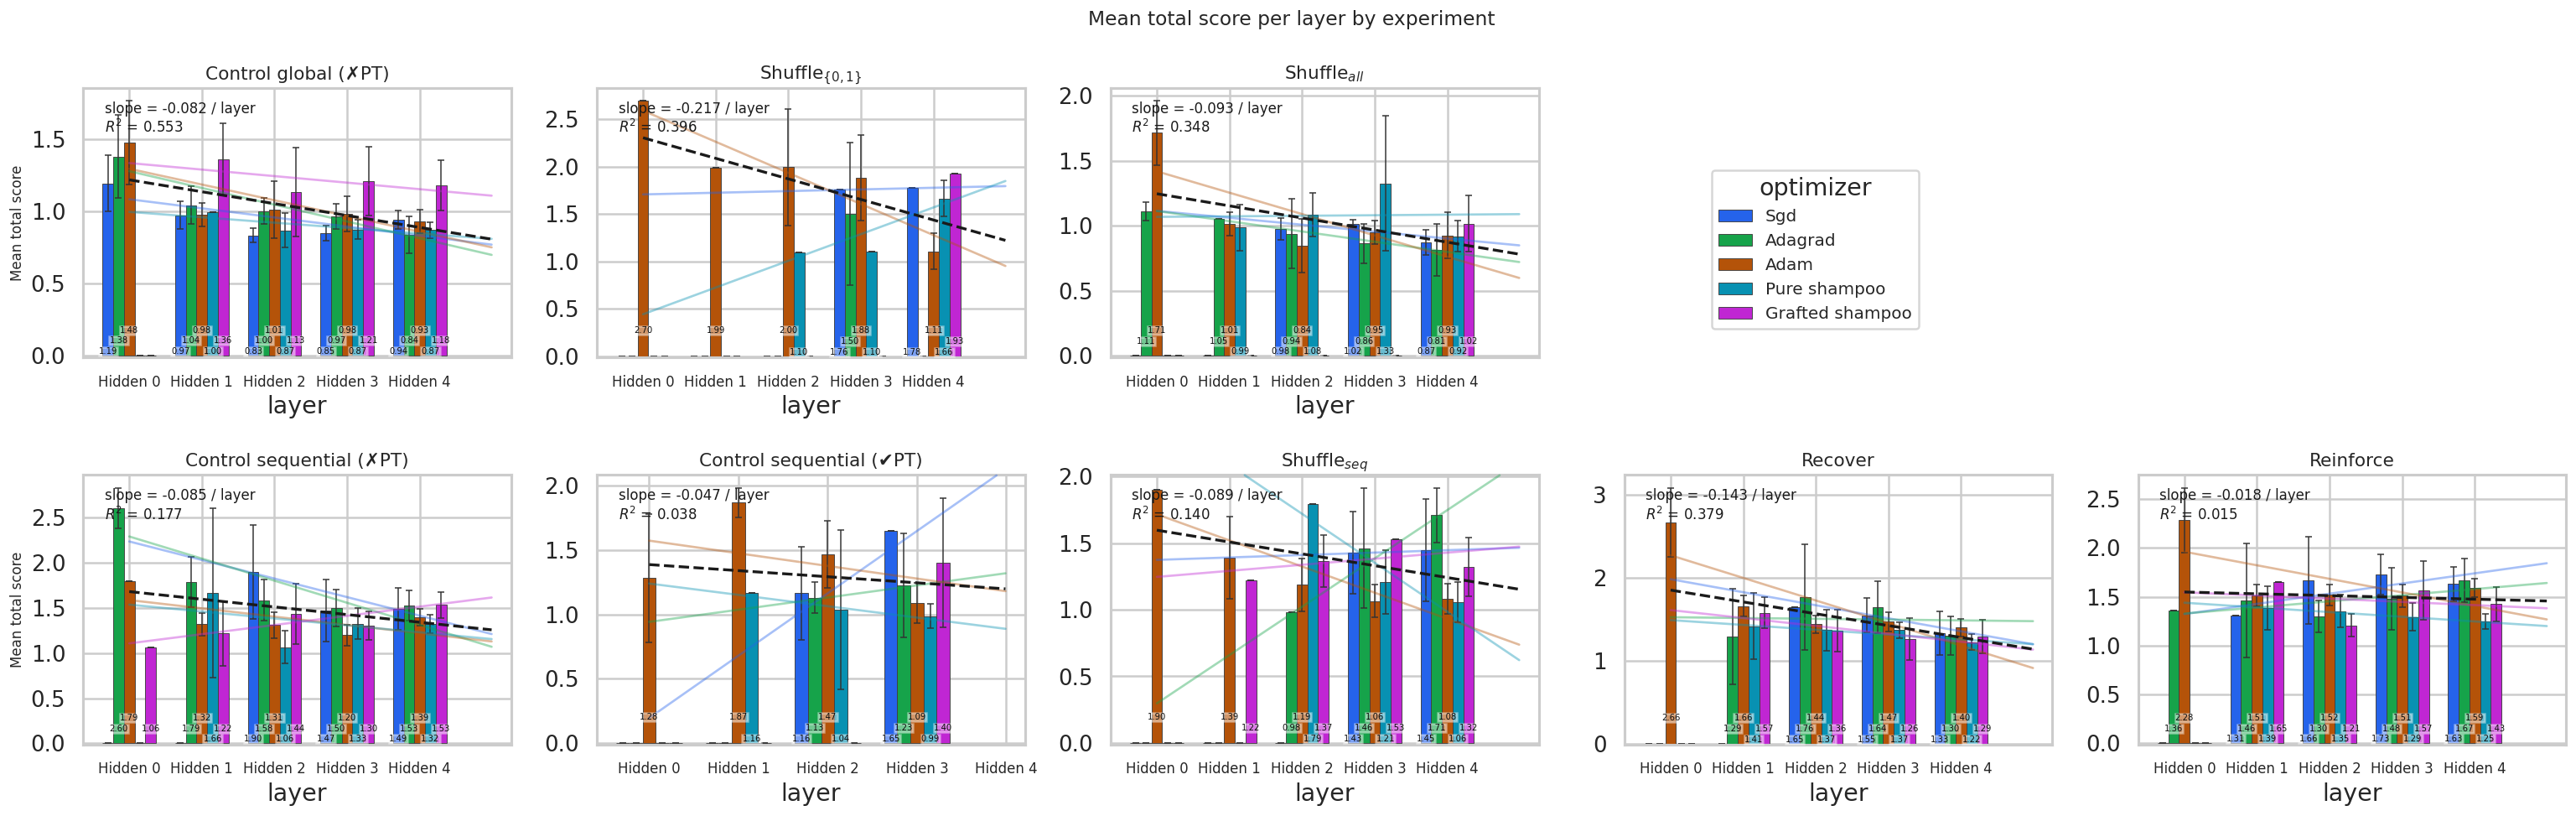

Saved additional_mean_score_per_layer_by_experiment.pdf


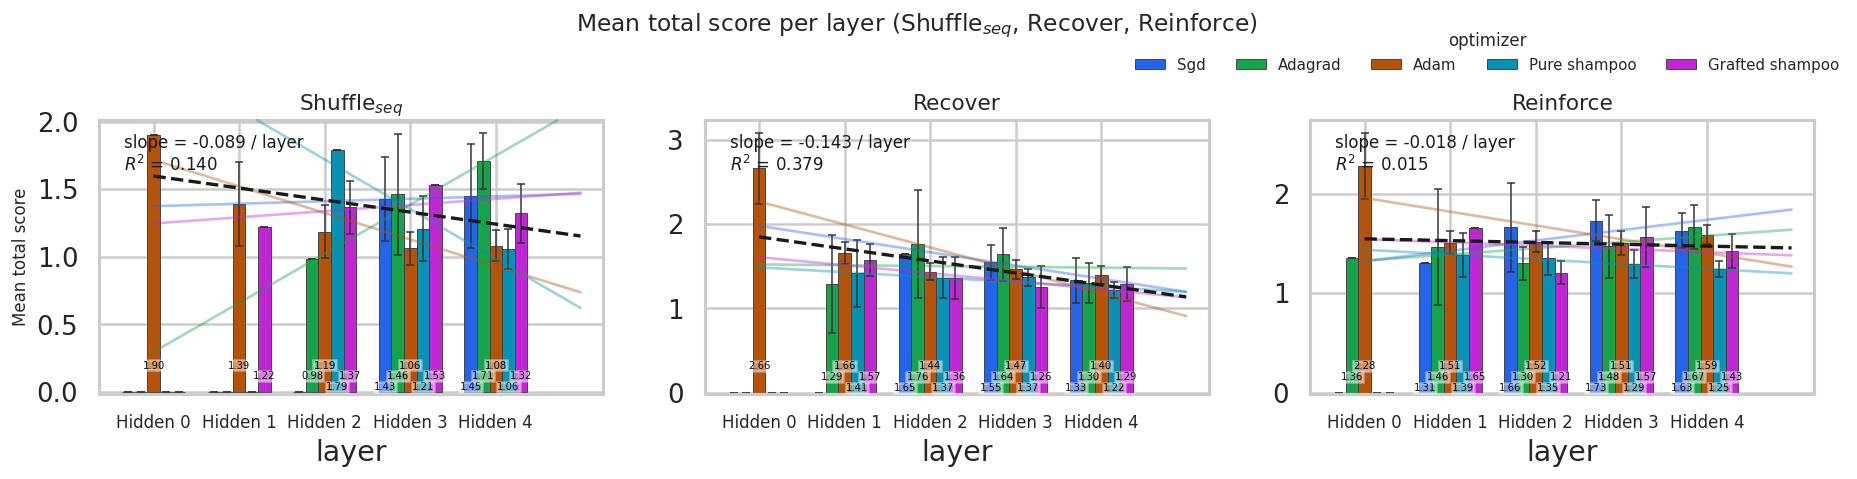

Saved additional_mean_score_per_layer_shuffle_recover_reinforce.pdf


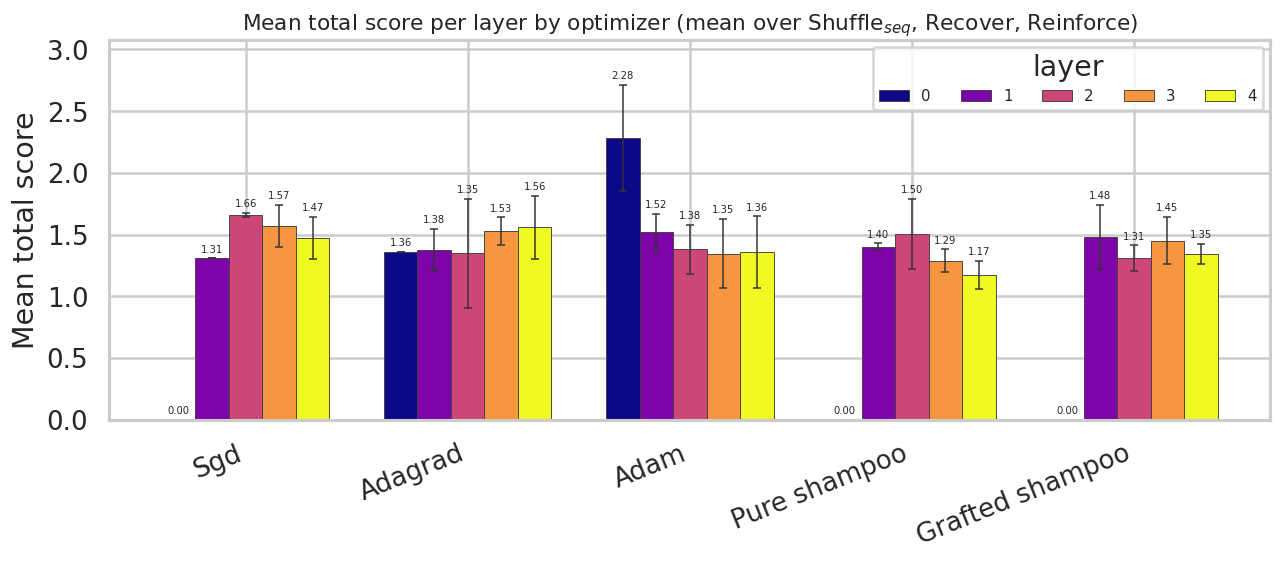

Saved additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf


In [10]:
# Score per layer: mean total_score across periods (hidden layers only), ±1.96 SEM
df_score_periods = build_layer_period_score_rows(all_results, rename_experiments)
df_score_periods = df_score_periods[df_score_periods["layer_name"].astype(str) != "head"]
print(f"score-per-period rows (for layer bar SEM): {len(df_score_periods)}")

df_score_layer = build_layer_mean_score_rows(all_results, rename_experiments)
df_score_layer = df_score_layer[df_score_layer["layer_name"].astype(str) != "head"]
print(f"score-per-run/layer rows (for across-layer printout): {len(df_score_layer)}")

print_mean_score_across_layers(
	df_score_layer,
	labels=LABELS,
	period_df=df_score_periods,
	sort_experiment_names=_sort_experiment_display_names,
)

_POOL_EXPS_SCORE = cat2_shuffle_recover_reinforce_labels(LABELS)
_POOL_TITLE_SUFFIX_SCORE = f"mean over {LABELS.shuffle_seq}, Recover, Reinforce"

if not df_score_periods.empty:
	agg_score = aggregate_layer_metric_mean_sem(
		df_score_periods,
		["experiment", "layer_name", "optimizer_id"],
		"total_score",
	)
	fig_score, _axes_score, plotted_score = facet_bar_by_experiment_cat12(
		agg_score,
		"experiment",
		"total_score",
		"Mean total score per layer by experiment",
		"Mean total score",
		"additional_mean_score_per_layer_by_experiment.pdf",
		plot_dir=PLOT_DIR,
		sort_experiment_names=_sort_experiment_display_names,
		labels=LABELS,
		sem_col="sem",
		annotate_bars=True,
		annotate_bars_inside=True,
		show=False,
		save=False,
	)
	if fig_score is not None:
		for ax, exp in plotted_score:
			sub = agg_score[agg_score["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
			overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
		fig_score.savefig(
			Path(PLOT_DIR) / "additional_mean_score_per_layer_by_experiment.pdf",
			bbox_inches="tight",
		)
		plt.show(fig_score)
		print("Saved additional_mean_score_per_layer_by_experiment.pdf")

	agg_score_cat2 = agg_score[agg_score["experiment"].astype(str).isin(_POOL_EXPS_SCORE)]
	fig_score_cat2, _axes_score_cat2, plotted_score_cat2 = facet_bar_by_experiment_row(
		agg_score_cat2,
		"experiment",
		_POOL_EXPS_SCORE,
		"total_score",
		f"Mean total score per layer ({LABELS.shuffle_seq}, Recover, Reinforce)",
		"Mean total score",
		"additional_mean_score_per_layer_shuffle_recover_reinforce.pdf",
		plot_dir=PLOT_DIR,
		sem_col="sem",
		annotate_bars=True,
		annotate_bars_inside=True,
		show=False,
		save=False,
	)
	if fig_score_cat2 is not None:
		for ax, exp in plotted_score_cat2:
			sub = agg_score_cat2[agg_score_cat2["experiment"] == exp]
			order_layers = _sort_layer_display_names(sub["layer_name"].unique())
			overlay_layer_group_mean_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
			overlay_layer_per_optimizer_regression(
				ax, sub, order_layers, "total_score", fill_missing_layers=False
			)
		fig_score_cat2.savefig(
			Path(PLOT_DIR)
			/ "additional_mean_score_per_layer_shuffle_recover_reinforce.pdf",
			bbox_inches="tight",
		)
		plt.show(fig_score_cat2)
		print("Saved additional_mean_score_per_layer_shuffle_recover_reinforce.pdf")

	agg_pooled_score = pool_btsp_mean_over_experiments(
		agg_score, "experiment", _POOL_EXPS_SCORE, "total_score"
	)
	if not agg_pooled_score.empty:
		plot_btsp_pooled_optimizer_layer_bars(
			agg_pooled_score,
			"total_score",
			"Mean total score",
			f"Mean total score per layer by optimizer ({_POOL_TITLE_SUFFIX_SCORE})",
			"additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf",
			plot_dir=PLOT_DIR,
			annotate_bars=True,
			annotate_bars_inside=False,
			show=True,
			save=True,
		)
		print(
			"Saved additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf"
		)
else:
	print("df_score_periods empty — skip score-per-layer plots")
